<a href="https://colab.research.google.com/github/Suongnhk/Vehicle-Insurance-Cross-Sell-Prediction/blob/main/%5BFINAL_PROJECT%5D_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preparation**

*Bộ train*

In [ ]:
!pip -q install gdown
import gdown, pandas as pd, pathlib

file_id = "1-kLJbJr4cgqG9ZbJp6U_ZzGaJLSMVnWb"  # ID từ link Drive của bạn
output_path = pathlib.Path("/content/data.csv")
gdown.download(id=file_id, output=str(output_path), quiet=False)

# Đọc CSV (tự đoán dấu phân cách; nếu biết chắc là ',', có thể dùng sep=',' để nhanh hơn)
df_train = pd.read_csv(output_path, sep=None, engine="python", encoding="utf-8")

print("Số dòng, cột:", df_train.shape)
df_train.head()

Downloading...
From: https://drive.google.com/uc?id=1-kLJbJr4cgqG9ZbJp6U_ZzGaJLSMVnWb
To: /content/data.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 69.9MB/s]


Số dòng, cột: (381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


*Bộ test*

In [ ]:
# ID mới từ link Drive
file_id = "1OWBdcnjvXQiBGceEqSeUug5vaYBuczTN"
output_path = pathlib.Path("/content/data2.csv")

# Tải file
gdown.download(id=file_id, output=str(output_path), quiet=False)

# Đọc CSV (tự động đoán dấu phân cách)
df_test = pd.read_csv(output_path, sep=None, engine="python", encoding="utf-8")

print("Số dòng, cột:", df_test.shape)
df_test.head()

Downloading...
From: https://drive.google.com/uc?id=1OWBdcnjvXQiBGceEqSeUug5vaYBuczTN
To: /content/data2.csv
100%|██████████| 6.93M/6.93M [00:00<00:00, 43.5MB/s]


Số dòng, cột: (127037, 11)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,381110,Male,25,1,11.0,1,< 1 Year,No,35786.0,152.0,53
1,381111,Male,40,1,28.0,0,1-2 Year,Yes,33762.0,7.0,111
2,381112,Male,47,1,28.0,0,1-2 Year,Yes,40050.0,124.0,199
3,381113,Male,24,1,27.0,1,< 1 Year,Yes,37356.0,152.0,187
4,381114,Male,27,1,28.0,1,< 1 Year,No,59097.0,152.0,297


Check

In [ ]:
print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (381109, 12)
Test: (127037, 11)


# **DATA UNDERSTANDING**

In [ ]:
# @title
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df_train.isnull().sum()

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [ ]:
missing_percentage = (df_train.isnull().sum() / len(df_train)) * 100
print(missing_percentage)

id                      0.0
Gender                  0.0
Age                     0.0
Driving_License         0.0
Region_Code             0.0
Previously_Insured      0.0
Vehicle_Age             0.0
Vehicle_Damage          0.0
Annual_Premium          0.0
Policy_Sales_Channel    0.0
Vintage                 0.0
Response                0.0
dtype: float64


In [ ]:
# --- 1. Check class balance (target variable) ---
def check_balance(df, target_col):
    balance = df[target_col].value_counts().to_frame(name='Count')
    balance['Percentage (%)'] = (balance['Count'] / len(df)) * 100
    return balance

# --- 2. Check duplicate rows ---
def check_duplicates(df, id_col=None):
    if id_col and id_col in df.columns:
        dup_count = df.duplicated(subset=[id_col]).sum()
    else:
        dup_count = df.duplicated().sum()  # Check duplicates across all columns
    return dup_count

# --- Run the functions ---
target_col = "Response"  # đổi nếu tên khác
id_col = "id"            # đổi nếu file test không có id thì bỏ

print("=== Dataset Balance Check ===")
print(check_balance(df_train, target_col))

print("\n=== Number of Duplicates ===")
print("Duplicate rows based on ID column:" if id_col else "Duplicate rows (all columns):",
      check_duplicates(df_train, id_col))


=== Dataset Balance Check ===
           Count  Percentage (%)
Response                        
0         334399       87.743664
1          46710       12.256336

=== Number of Duplicates ===
Duplicate rows based on ID column: 0


In [ ]:
category_data = df_train[['Gender','Previously_Insured','Vehicle_Age','Vehicle_Damage','Response','Driving_License']]
continuous_data = df_train[['Age','Annual_Premium','Vintage']]

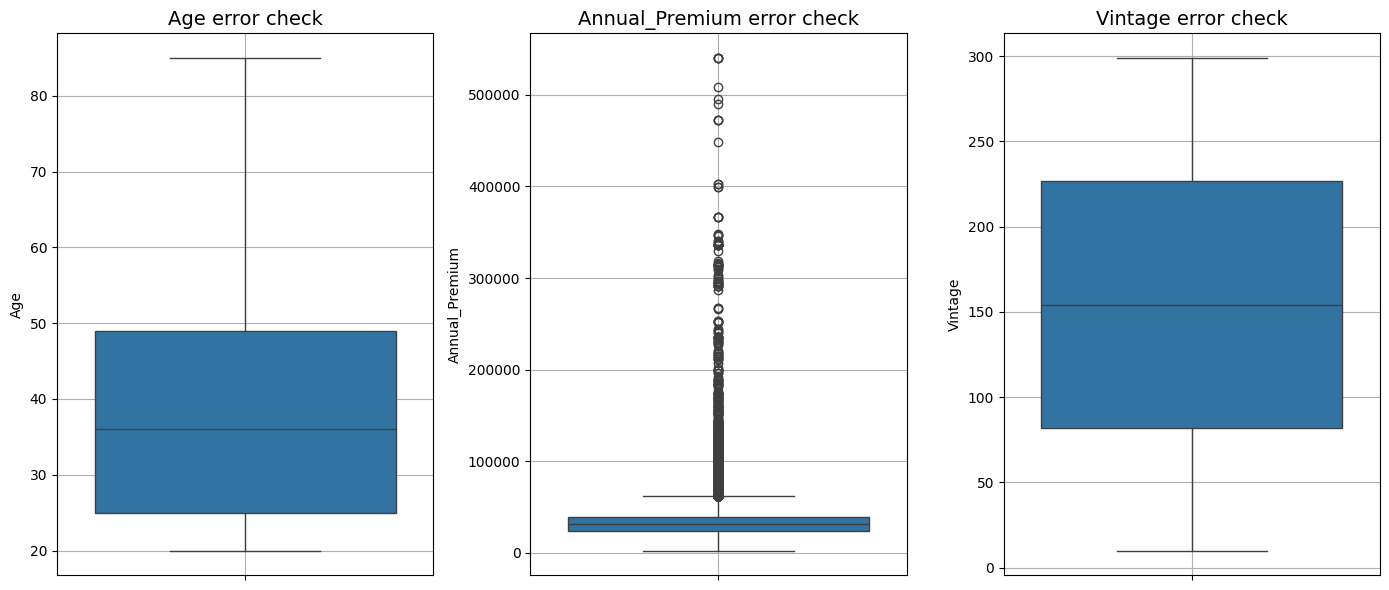

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(14,6))
for i in range(3):
    sns.boxplot(continuous_data[continuous_data.columns[i]],ax=ax[i])
    ax[i].set_title(continuous_data.columns[i] + ' error check',fontsize=14)
    ax[i].grid()
plt.tight_layout()
plt.show()

# **Data Exploratory**

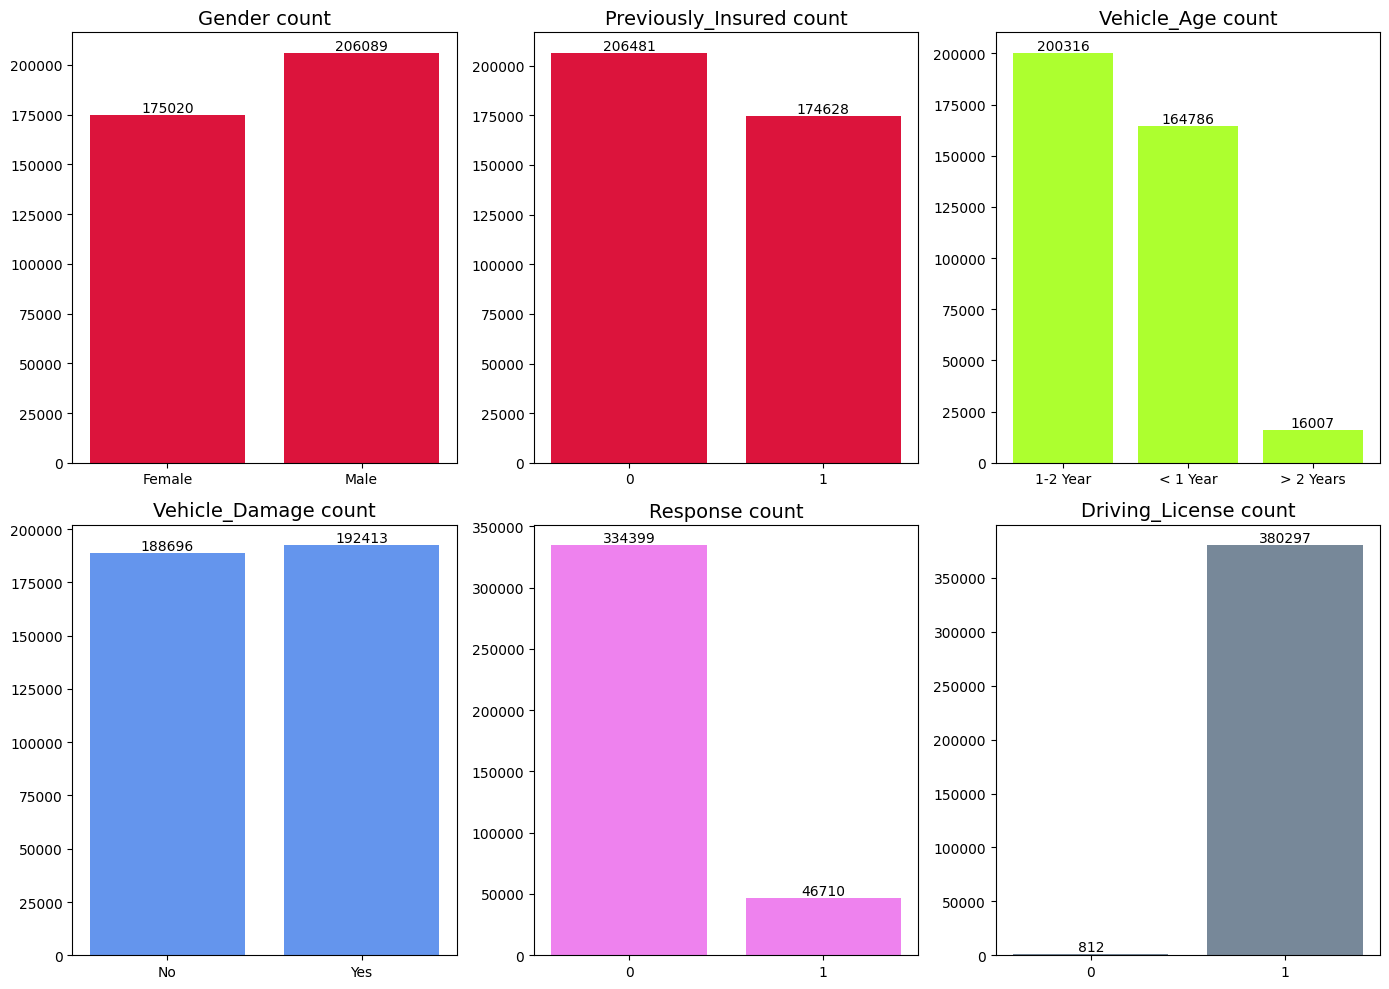

In [ ]:
plt.figure(figsize=(14,10))
color_ls = ['#DC143C','#DC143C','#ADFF2F','#6495ED','#EE82EE','#778899']
for i in range(6):
    plt.subplot(2,3,i + 1)
    plt.title(category_data.columns[i] + ' count',fontsize=14)
    col_count = category_data[category_data.columns[i]].value_counts().sort_index()
    plt.bar(col_count.index,col_count.values,color=color_ls[i])
    plt.xticks(col_count.index)
    for i in range(len(col_count)):
        plt.text(i,col_count.values[i],str(col_count.values[i]),va='bottom',ha='center')
plt.tight_layout()
plt.show()

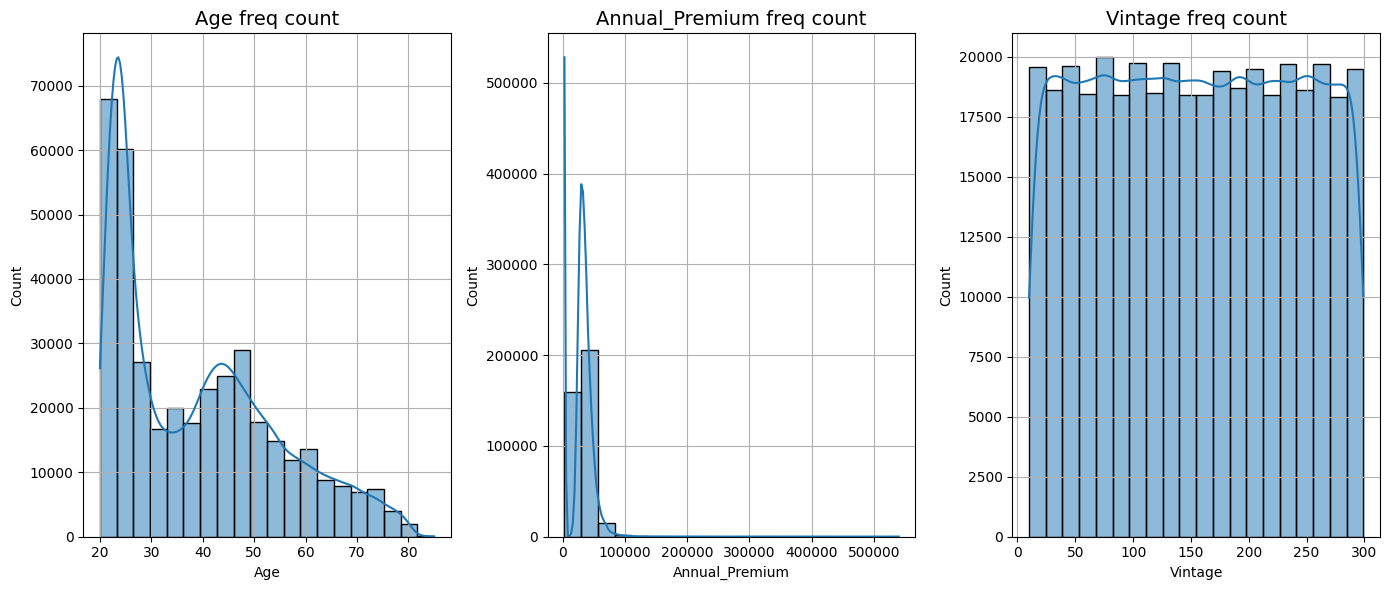

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(14,6))
for i in range(3):
    sns.histplot(continuous_data[continuous_data.columns[i]],ax=ax[i],kde=True,bins=20)
    ax[i].set_title(continuous_data.columns[i] + ' freq count',fontsize=14)
    ax[i].grid()
plt.tight_layout()
plt.show()

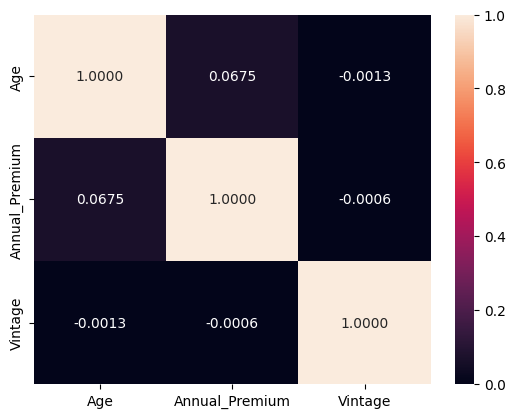

In [ ]:
sns.heatmap(continuous_data.corr(),annot=True,fmt='.4f')
plt.show()

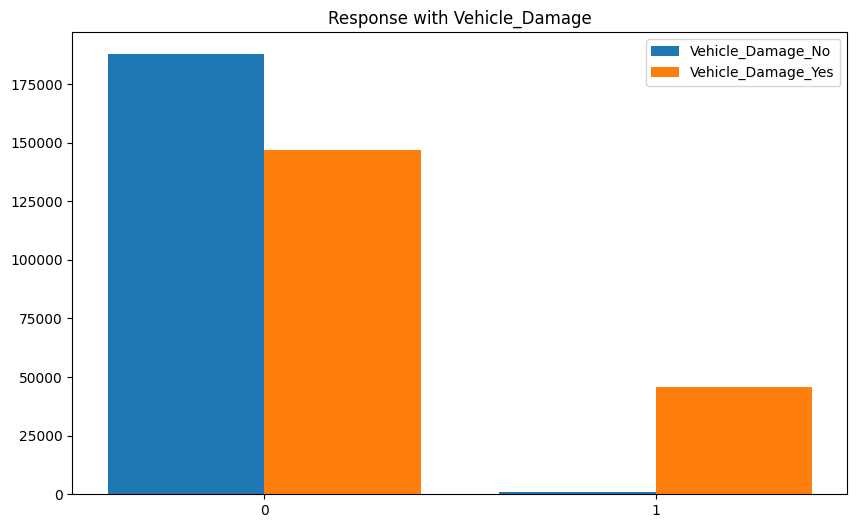

In [ ]:
is_damage = df_train.groupby(['Vehicle_Damage','Response']).agg({"id":'count'}).rename({'id':'Count'},axis=1).reset_index()
no_damage = is_damage[is_damage['Vehicle_Damage'] == 'No']
yes_damage = is_damage[is_damage['Vehicle_Damage'] == 'Yes']
plt.figure(figsize=(10,6))
plt.bar(no_damage['Response'] - 0.20,no_damage['Count'],width=0.4,label='Vehicle_Damage_No')
plt.bar(yes_damage['Response'] + 0.20,yes_damage['Count'],width=0.4,label='Vehicle_Damage_Yes')
plt.xticks(yes_damage['Response'])
plt.title('Response with Vehicle_Damage')
plt.legend()
plt.show()

In [ ]:
indicate_region = pd.DataFrame()
for i in df_train['Region_Code'].value_counts().iloc[:8].index:
    indicate_region = pd.concat([indicate_region,df_train[df_train['Region_Code'] == i]])

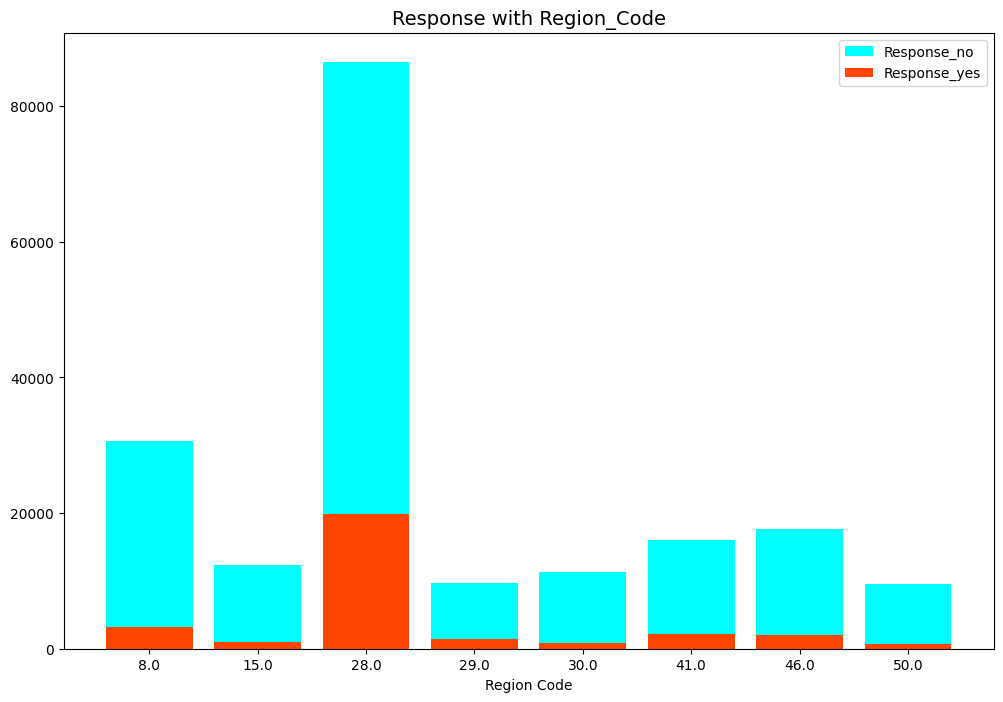

In [ ]:
region_response = indicate_region.groupby(['Region_Code','Response']).agg({'id':'count'}).rename({'id':'Count'},axis=1).reset_index()
no_response = region_response[region_response['Response'] == 0]
yes_response = region_response[region_response['Response'] == 1]
plt.figure(figsize=(12,8))
plt.bar(no_response['Region_Code'].astype('str'),no_response['Count'],color='#00FFFF',label='Response_no')
plt.bar(yes_response['Region_Code'].astype('str'),yes_response['Count'],color='#FF4500',label='Response_yes')
plt.title('Response with Region_Code',fontsize=14)
plt.xlabel('Region Code')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.histplot(df_train['Region_Code'], bins=35, kde=True, color='blue', edgecolor='black')
plt.title('Region Code Distribution', fontsize=20)
plt.xlabel('Region Code', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
# === Giữ nguyên phần chuẩn bị dữ liệu của bạn ===
is_prev = df_train.groupby(['Previously_Insured','Response']).agg({'id':'count'}) \
                  .rename({'id':'Count'}, axis=1).reset_index()

# Bảo đảm thứ tự lớp [0,1] để explode/màu ăn khớp (không đổi nội dung)
def get_counts(df, prev_flag):
    sub = df[df['Previously_Insured'] == prev_flag]
    sub = sub.set_index('Response')['Count'].reindex([0, 1], fill_value=0)
    labels = sub.index.tolist()          # giữ nhãn gốc (0/1)
    values = sub.values.tolist()
    return labels, values

labels_prev, vals_prev   = get_counts(is_prev, 0)   # Previously_Insured = 0
labels_nprev, vals_nprev = get_counts(is_prev, 1)   # Previously_Insured = 1

# === Format giống hệt chart mẫu ===
explode = (0.1, 0)
colors  = ['lightgreen', 'lightcoral']

plt.figure(figsize=(12, 8))

# Subplot 1
plt.subplot(1, 2, 1)
plt.pie(vals_prev,
        labels=labels_prev,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True,
        explode=explode)
plt.title('Have previously Insured', fontsize=14)
plt.legend(loc="best")

# Subplot 2
plt.subplot(1, 2, 2)
plt.pie(vals_nprev,
        labels=labels_nprev,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True,
        explode=explode)
plt.title('No previously Insured', fontsize=14)
plt.legend(loc="best")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(18, 8))
custom_palette = ['#2c3e50', '#e74c3c']

sns.countplot(x='Age', hue='Response', data=df_train, palette=custom_palette)
plt.title('Count of Responses by Age', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Response', fontsize=12)
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))
custom_palette = ['#6a0dad', '#9370db', '#dda0dd']

sns.barplot(x='Vehicle_Age', y='Response', hue='Vehicle_Damage', data=df_train, palette=custom_palette)
plt.title('Response by Vehicle Age and Damage', fontsize=16)
plt.xlabel('Vehicle Age', fontsize=14)
plt.ylabel('Response', fontsize=14)
plt.legend(title='Vehicle Damage', fontsize=12)
plt.show()

In [ ]:
if all(column in df_train.columns and df_train[column].nunique() > 1 for column in ['Vehicle_Age', 'Vehicle_Damage']):
    vehicle_age_counts = df_train['Vehicle_Age'].value_counts()
    vehicle_damage_counts = df_train['Vehicle_Damage'].value_counts()

    fig, ax = plt.subplots(figsize=(10, 10))

    explode_outer = (0.1, 0, 0)
    ax.pie(vehicle_age_counts, labels=vehicle_age_counts.index, autopct='%1.1f%%',
           colors=['lightblue', 'lightgreen', 'lightcoral'], radius=1, shadow=True, explode=explode_outer,
           wedgeprops=dict(width=0.3, edgecolor='w'))

    explode_inner = (0.1, 0)
    ax.pie(vehicle_damage_counts, labels=vehicle_damage_counts.index, autopct='%1.1f%%',
           colors=['skyblue', 'lightcoral'], radius=0.7, shadow=True, explode=explode_inner,
           wedgeprops=dict(width=0.3, edgecolor='w'))

    ax.set(aspect="equal", title='Nested Pie Plot of Vehicle Age and Vehicle Damage')
    plt.legend(loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.show()
else:
    print("One or both of the 'Vehicle_Age' or 'Vehicle_Damage' columns are missing or do not have enough categories to plot.")

In [ ]:
if 'Response' in df_train.columns and df_train['Response'].nunique() > 1:
    response_counts = df_train['Response'].value_counts()

    plt.figure(figsize=(8, 8))
    explode = (0.1, 0)

    plt.pie(response_counts, labels=['No Response', 'Positive Response'], autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'], startangle=90, shadow=True, explode=explode)

    plt.title('Response Proportions', fontsize=14)
    plt.legend(loc="best")
    plt.show()
else:
    print("The 'Response' column is missing or does not have enough categories to plot.")

In [ ]:
if 'Gender' in df_train.columns and df_train['Gender'].nunique() > 1:
	gender_counts = df_train['Gender'].value_counts()

	plt.figure(figsize=(8, 8))
	explode = (0.1, 0)
	plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
			colors=['skyblue', 'lightcoral'], startangle=90, shadow=True, explode=explode)

	plt.title('Gender Distribution', fontsize=14)
	plt.legend(loc='best')
	plt.show()
else:
	print("The 'Gender' column is missing or does not have enough categories to plot.")

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
bin_size = int((df_train['Age'].max() - df_train['Age'].min()) / 30)

sns.histplot(df_train['Age'], bins=bin_size, kde=True, edgecolor='black', color='darkturquoise')

plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

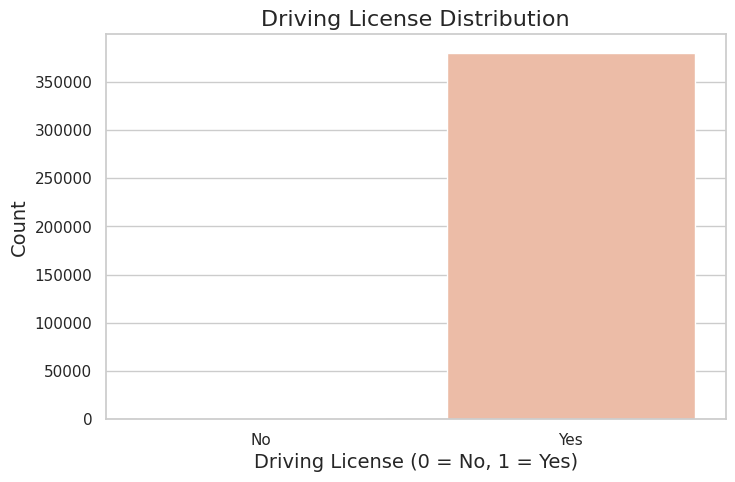

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Driving_License', data=df_train, palette='coolwarm')
plt.title('Driving License Distribution', fontsize=16)
plt.xlabel('Driving License (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

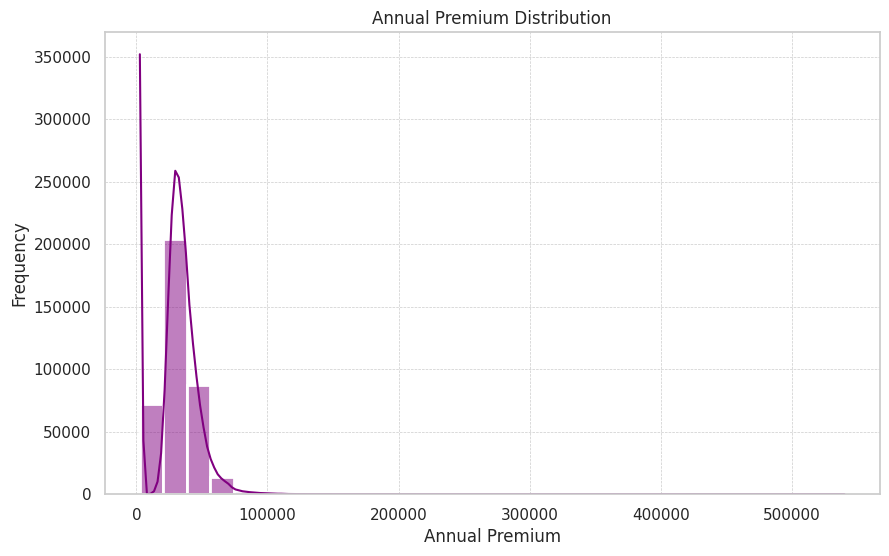

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_train['Annual_Premium'], bins=30, kde=True, color='purple', linewidth=2)
plt.title('Annual Premium Distribution')
plt.xlabel('Annual Premium')
plt.ylabel('Frequency')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

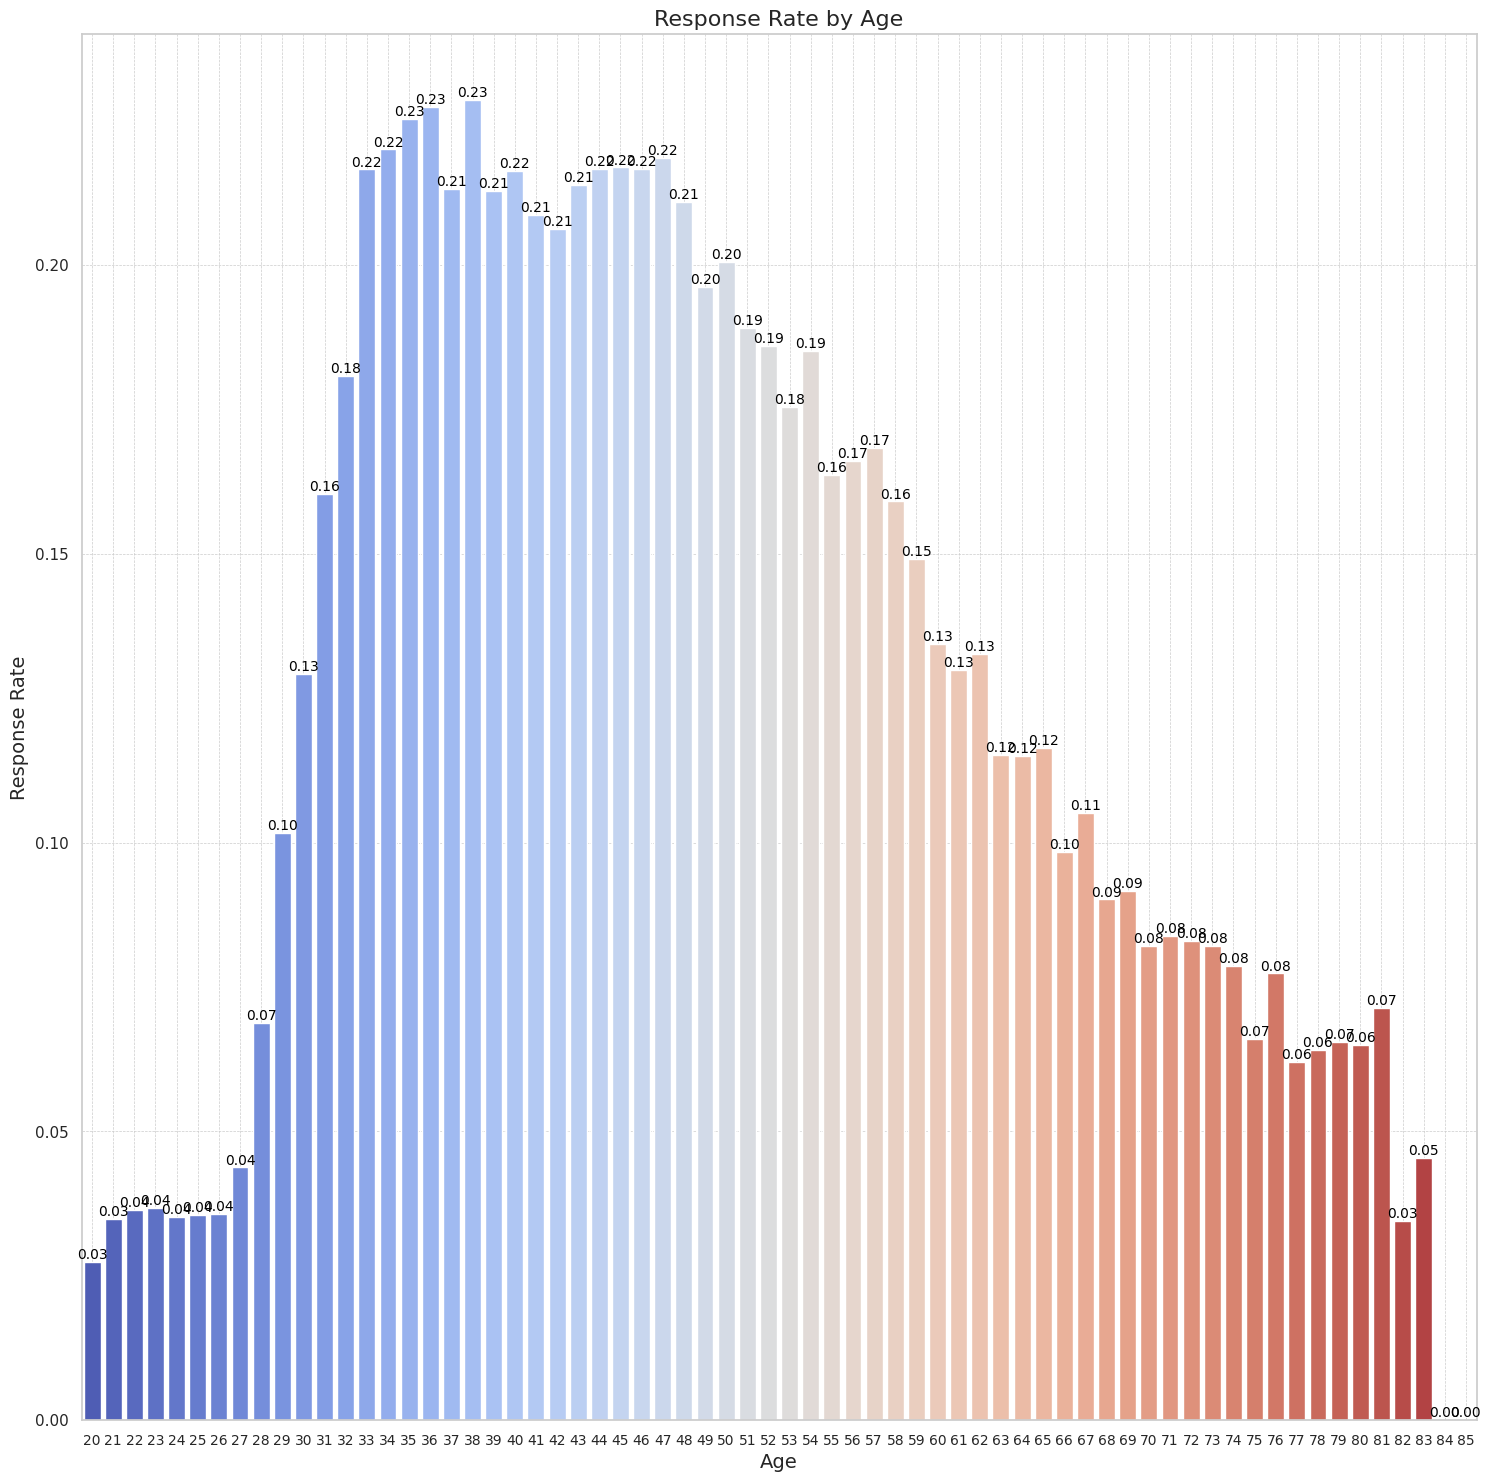

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 18))
age_response = df_train.groupby('Age')['Response'].mean().reset_index()
sns.barplot(x='Age', y='Response', data=age_response, palette='coolwarm')
plt.title('Response Rate by Age', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Response Rate', fontsize=14)
plt.xticks(rotation=0, fontsize=10)
for index, row in age_response.iterrows():
    plt.text(row.name, row.Response, f'{row.Response:.2f}', color='black', ha="center", va="bottom", fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

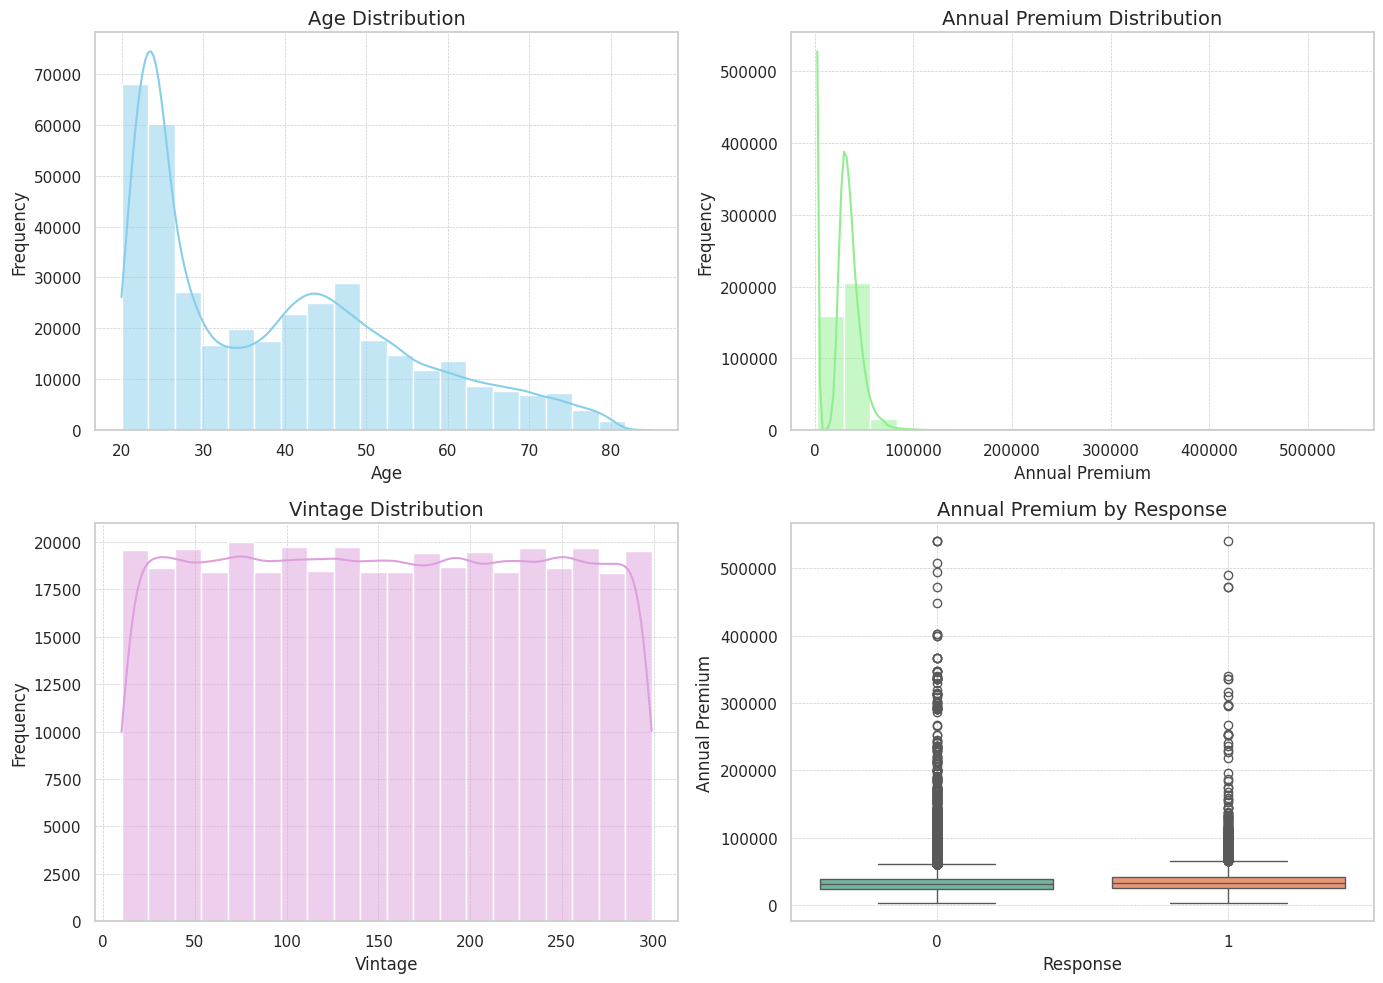

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 10))

# Subplot 1: Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(df_train['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 2: Annual Premium Distribution
plt.subplot(2, 2, 2)
sns.histplot(df_train['Annual_Premium'], bins=20, kde=True, color='lightgreen')
plt.title('Annual Premium Distribution', fontsize=14)
plt.xlabel('Annual Premium', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 3: Vintage Distribution
plt.subplot(2, 2, 3)
sns.histplot(df_train['Vintage'], bins=20, kde=True, color='plum')
plt.title('Vintage Distribution', fontsize=14)
plt.xlabel('Vintage', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 4: Annual Premium by Response
plt.subplot(2, 2, 4)
sns.boxplot(x='Response', y='Annual_Premium', data=df_train, palette='Set2')
plt.title('Annual Premium by Response', fontsize=14)
plt.xlabel('Response', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Adjusting the layout to prevent overlap
plt.tight_layout()
plt.show()

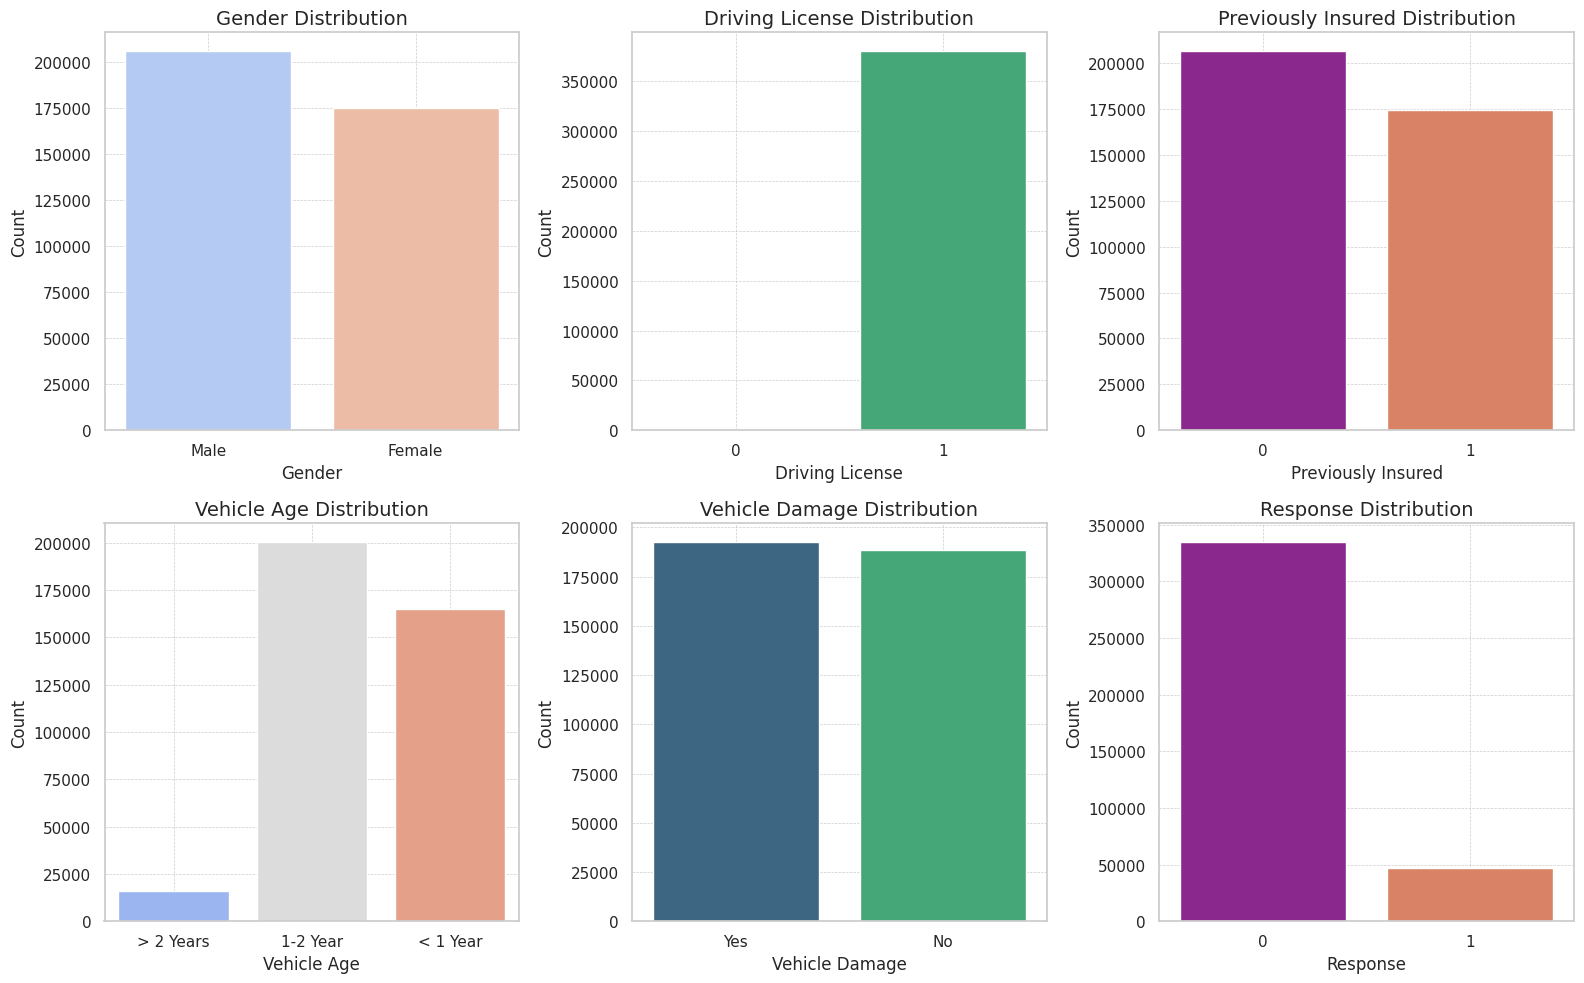

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

# Subplot 1: Gender Distribution
plt.subplot(2, 3, 1)
sns.countplot(x='Gender', data=df_train, palette='coolwarm')
plt.title('Gender Distribution', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 2: Driving License Distribution
plt.subplot(2, 3, 2)
sns.countplot(x='Driving_License', data=df_train, palette='viridis')
plt.title('Driving License Distribution', fontsize=14)
plt.xlabel('Driving License', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 3: Previously Insured Distribution
plt.subplot(2, 3, 3)
sns.countplot(x='Previously_Insured', data=df_train, palette='plasma')
plt.title('Previously Insured Distribution', fontsize=14)
plt.xlabel('Previously Insured', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 4: Vehicle Age Distribution
plt.subplot(2, 3, 4)
sns.countplot(x='Vehicle_Age', data=df_train, palette='coolwarm')
plt.title('Vehicle Age Distribution', fontsize=14)
plt.xlabel('Vehicle Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 5: Vehicle Damage Distribution
plt.subplot(2, 3, 5)
sns.countplot(x='Vehicle_Damage', data=df_train, palette='viridis')
plt.title('Vehicle Damage Distribution', fontsize=14)
plt.xlabel('Vehicle Damage', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

# Subplot 6: Response Distribution
plt.subplot(2, 3, 6)
sns.countplot(x='Response', data=df_train, palette='plasma')
plt.title('Response Distribution', fontsize=14)
plt.xlabel('Response', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

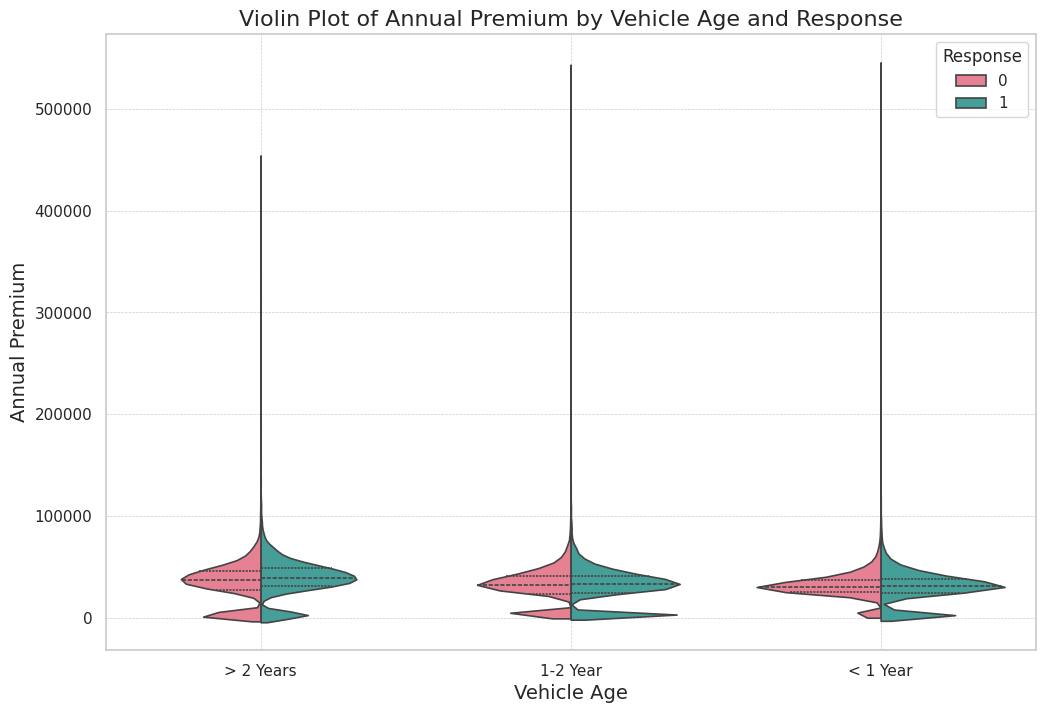

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.violinplot(x='Vehicle_Age', y='Annual_Premium', data=df_train, hue='Response', split=True,
               palette='husl', inner='quartile', linewidth=1.2)
plt.title('Violin Plot of Annual Premium by Vehicle Age and Response', fontsize=16)
plt.xlabel('Vehicle Age', fontsize=14)
plt.ylabel('Annual Premium', fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

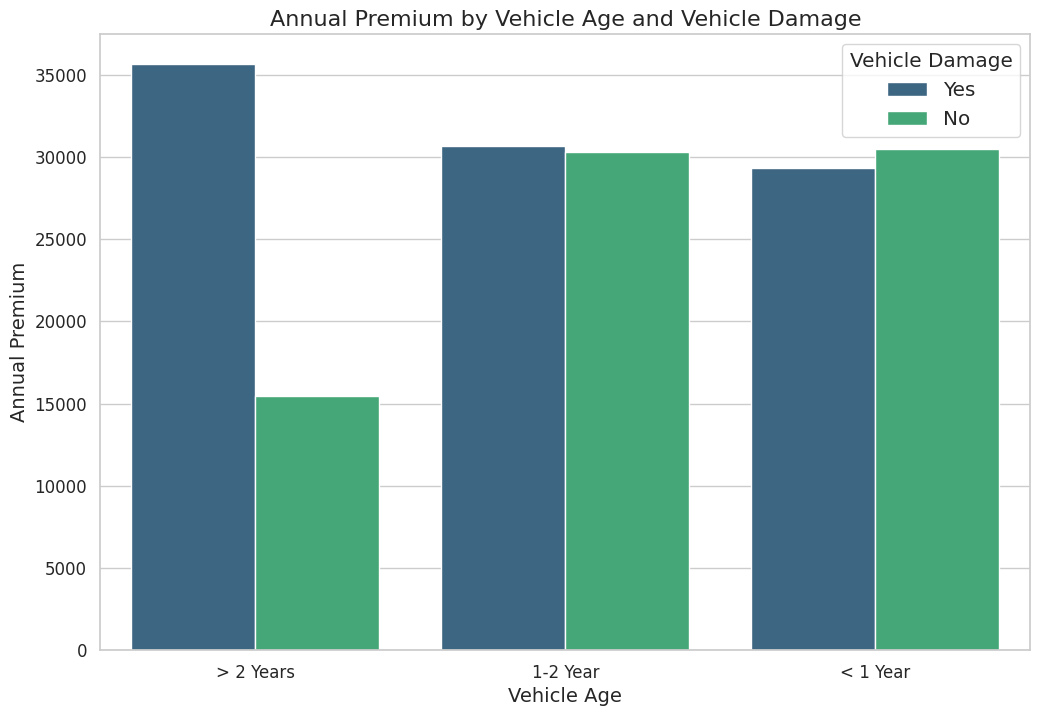

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.barplot(x='Vehicle_Age', y='Annual_Premium', hue='Vehicle_Damage', data=df_train, palette='viridis', ci=None)
plt.title('Annual Premium by Vehicle Age and Vehicle Damage', fontsize=16)
plt.xlabel('Vehicle Age', fontsize=14)
plt.ylabel('Annual Premium', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Vehicle Damage', title_fontsize='large', fontsize='large')
plt.show()

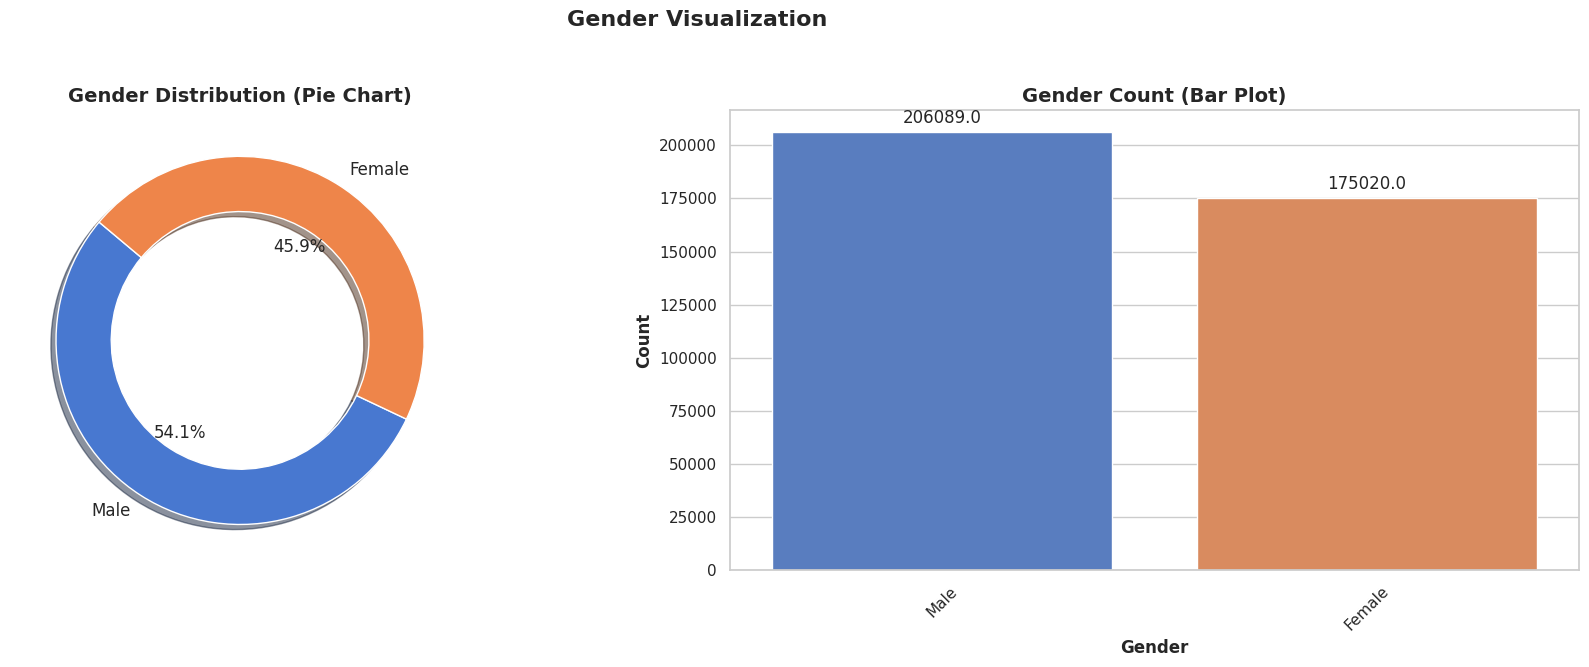

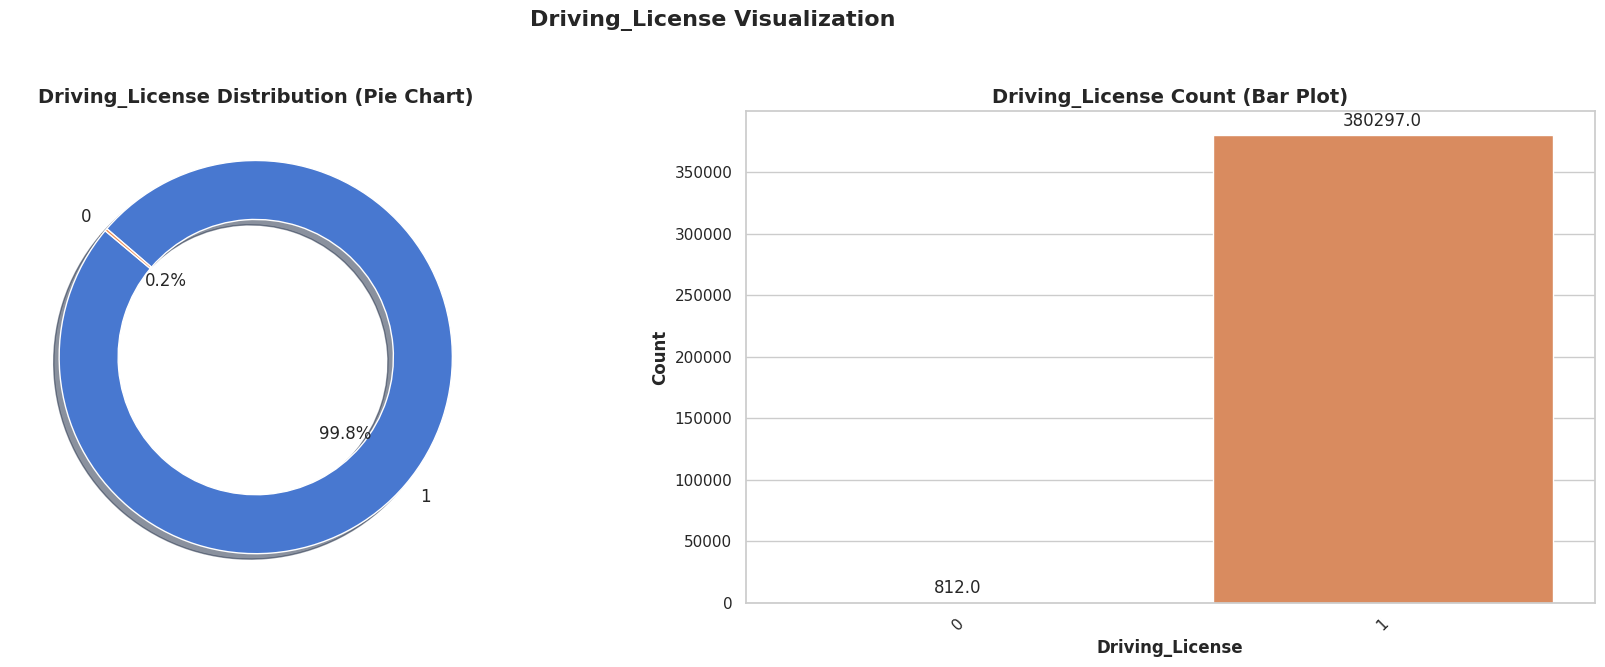

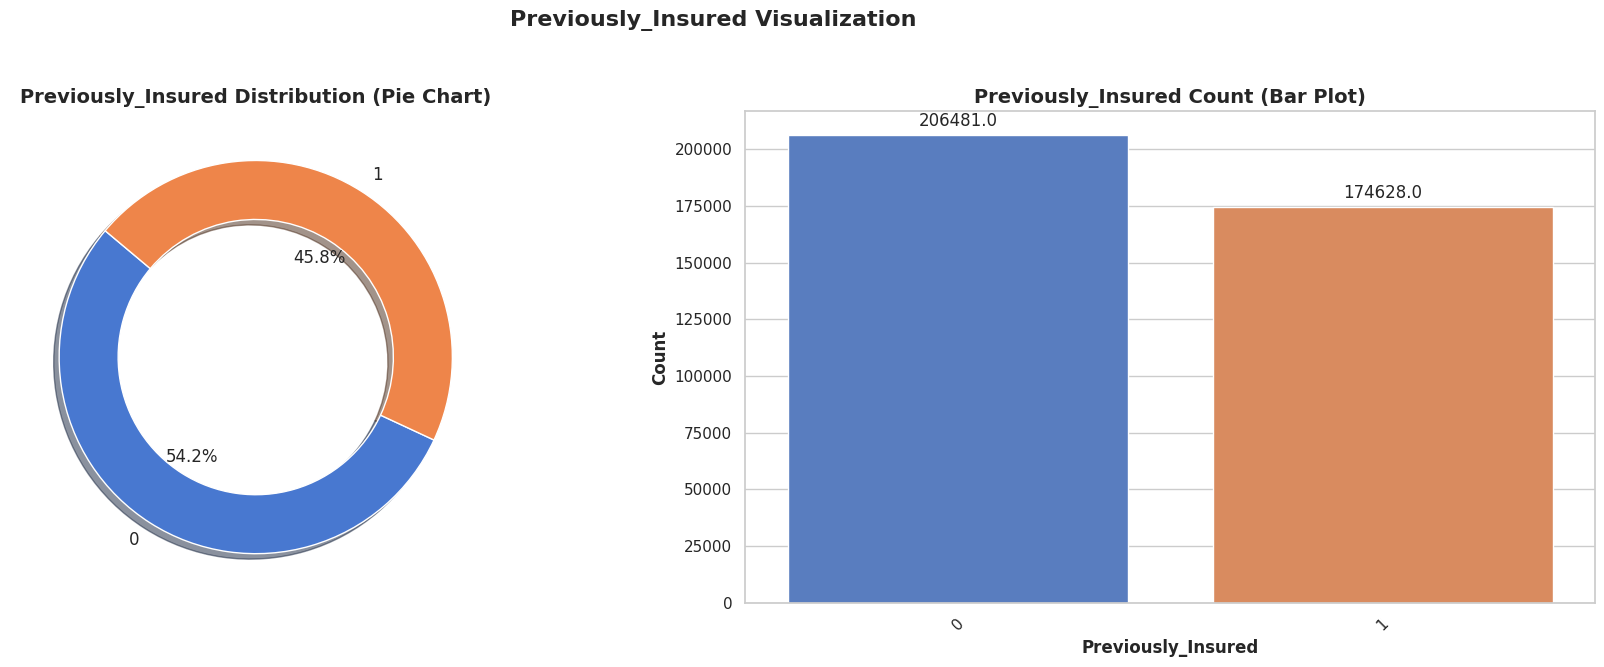

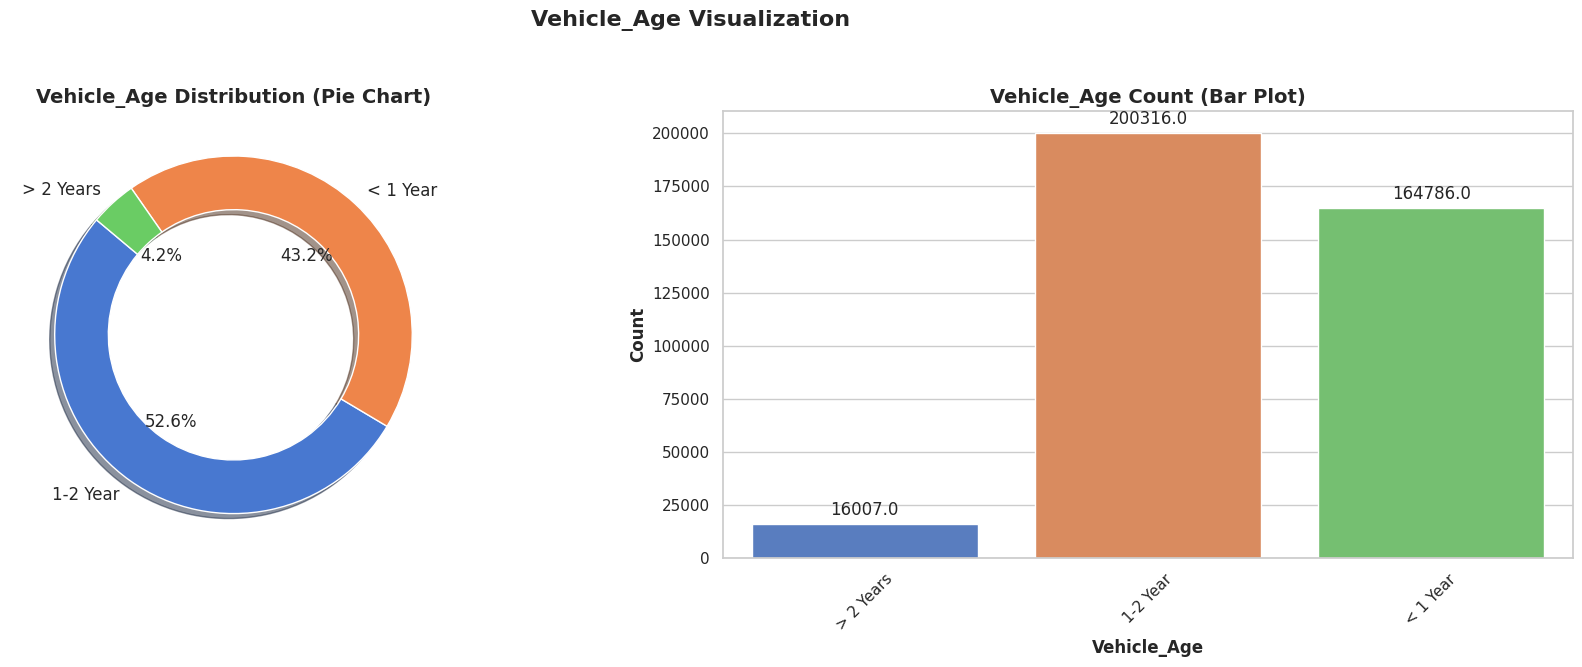

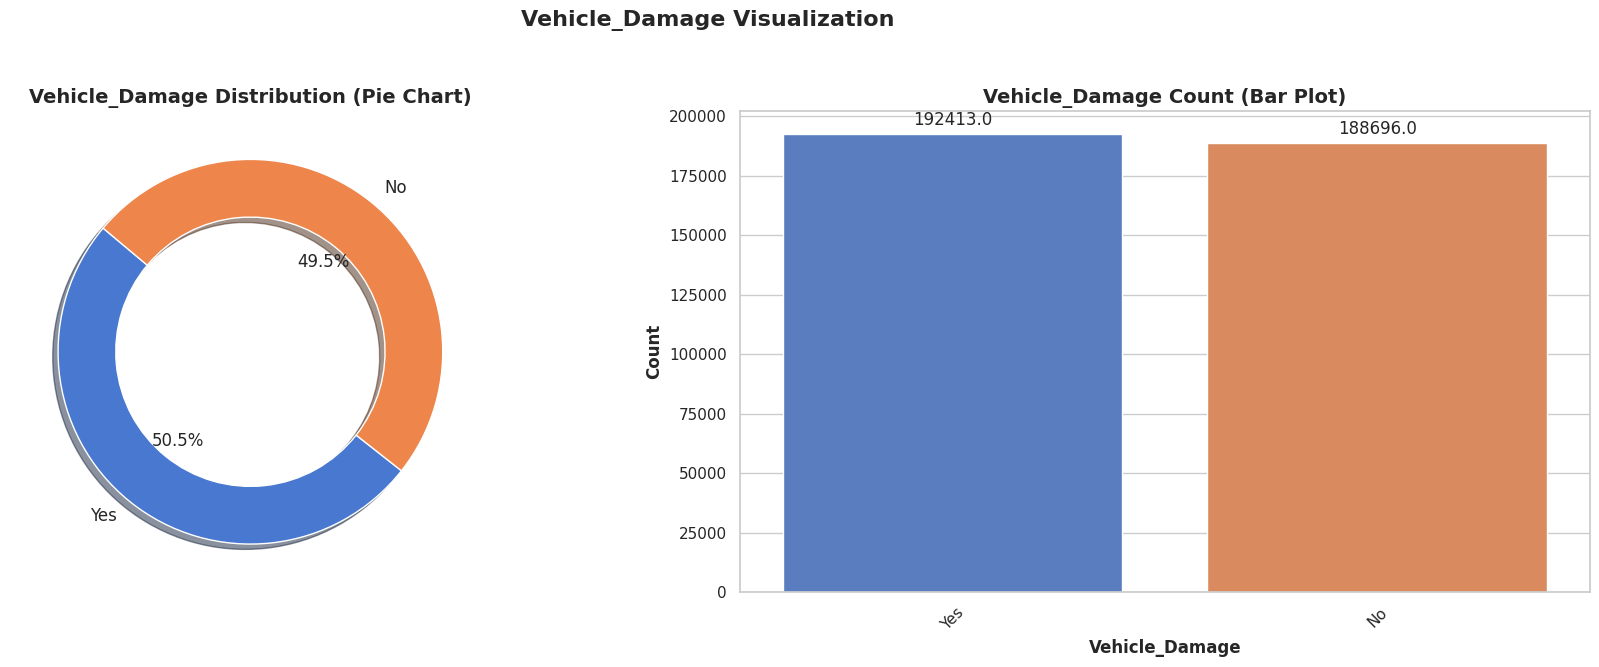

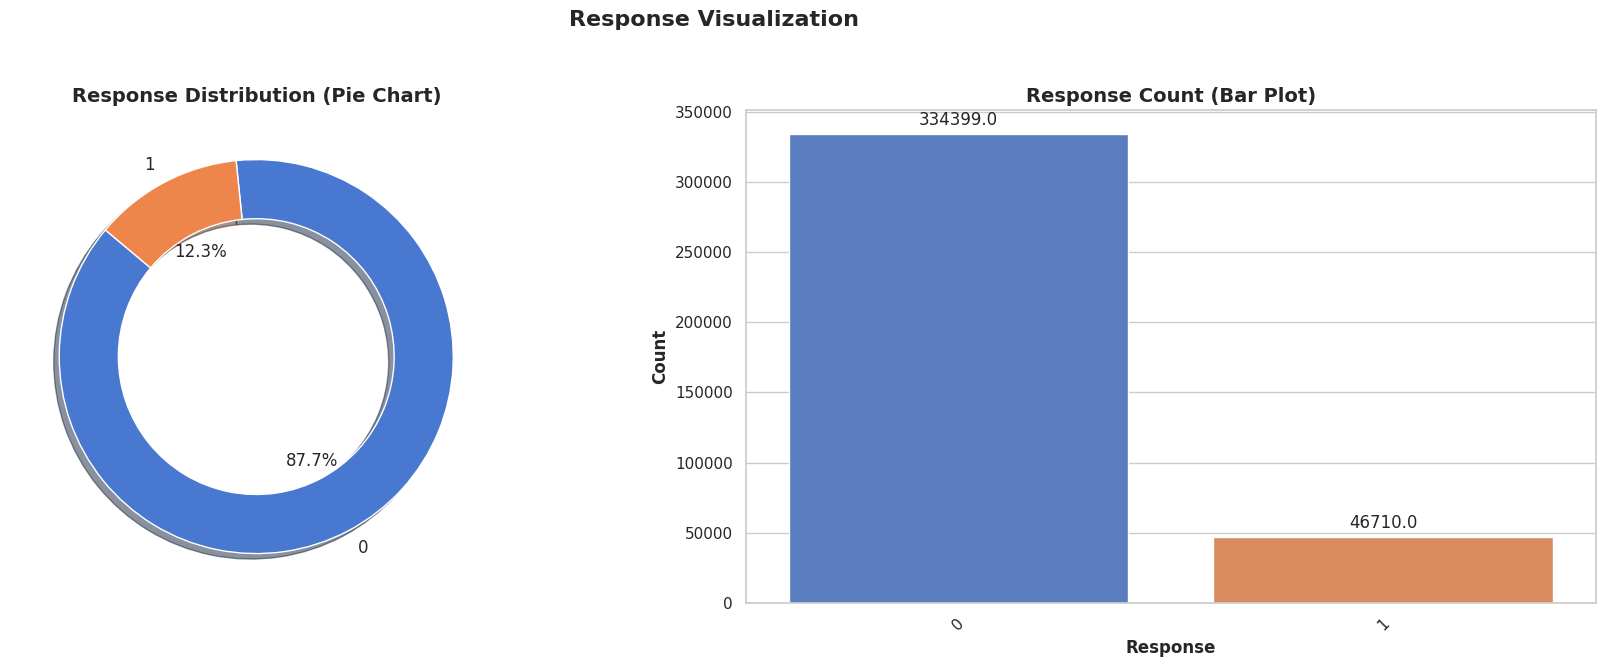

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming train_eda is your DataFrame

unique_counts = df_train.nunique()

threshold = 12
continuous_vars = unique_counts[unique_counts > threshold].index.tolist()
categorical_vars = unique_counts[unique_counts <= threshold].index.tolist()
if 'id' in continuous_vars:
    continuous_vars.remove('id')

custom_palette = sns.color_palette("muted")

for column in categorical_vars:
    f, ax = plt.subplots(1, 2, figsize=(18, 7))

    # Pie Chart
    df_train[column].value_counts().plot.pie(
        autopct='%1.1f%%', ax=ax[0], shadow=True, colors=custom_palette, startangle=140,
        wedgeprops=dict(width=0.3, edgecolor='w'), textprops={'fontsize': 12})
    ax[0].set_ylabel('')
    ax[0].set_title(f'{column} Distribution (Pie Chart)', fontsize=14, fontweight='bold')

    # Bar Plot
    sns.countplot(x=column, data=df_train, ax=ax[1], palette=custom_palette)
    ax[1].set_xlabel(f'{column}', fontsize=12, fontweight='bold')
    ax[1].set_ylabel('Count', fontsize=12, fontweight='bold')
    ax[1].set_title(f'{column} Count (Bar Plot)', fontsize=14, fontweight='bold')

    # Rotate x-ticks for better readability
    ax[1].tick_params(axis='x', rotation=45)

    # Add annotations to the bar plot
    for p in ax[1].patches:
        height = p.get_height()
        ax[1].annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

    plt.suptitle(f'{column} Visualization', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit titles
    plt.show()

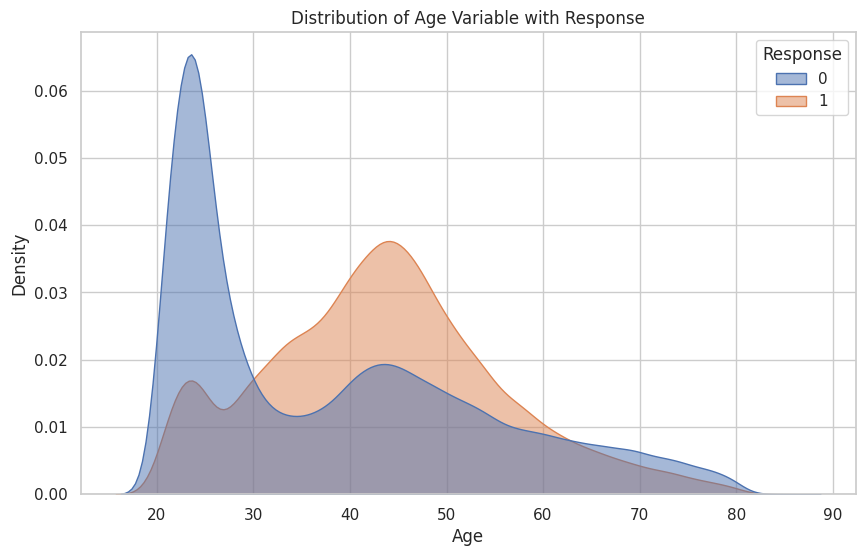

In [ ]:
import warnings
warnings.filterwarnings("ignore")
with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=df_train, x='Age', hue='Response', fill=True, common_norm=False, alpha=0.5)
        plt.title('Distribution of Age Variable with Response')
        plt.xlabel('Age')
        plt.ylabel('Density')
        plt.show()

# **Data Preprocessing**

***Outlier***

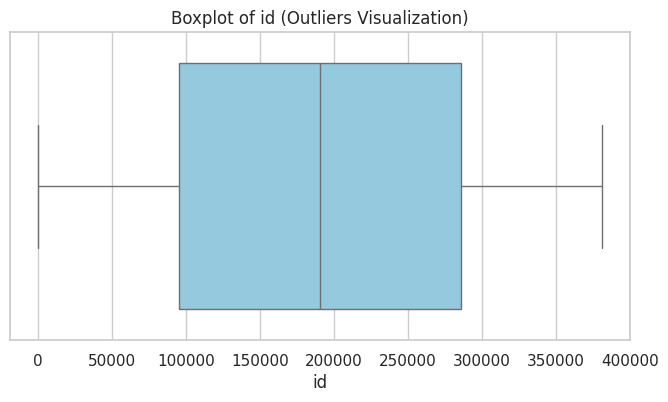

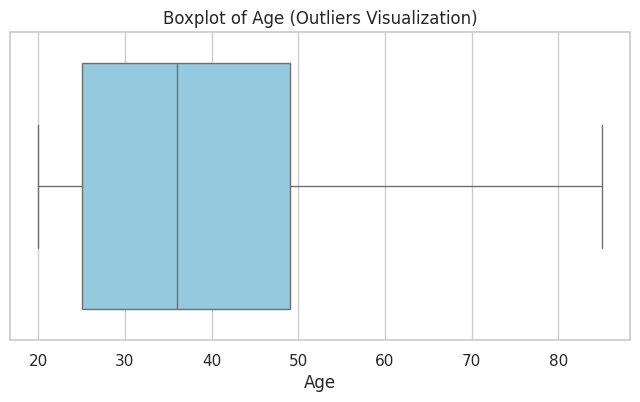

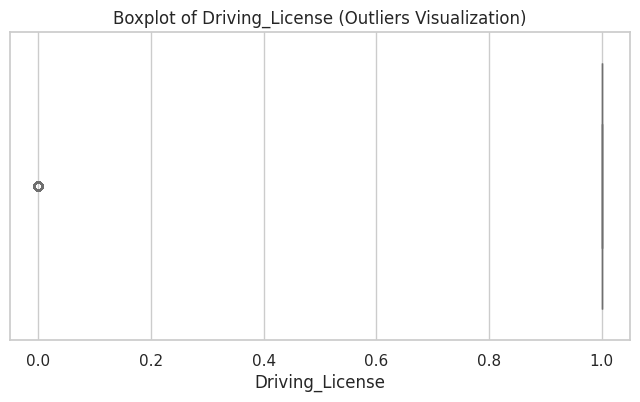

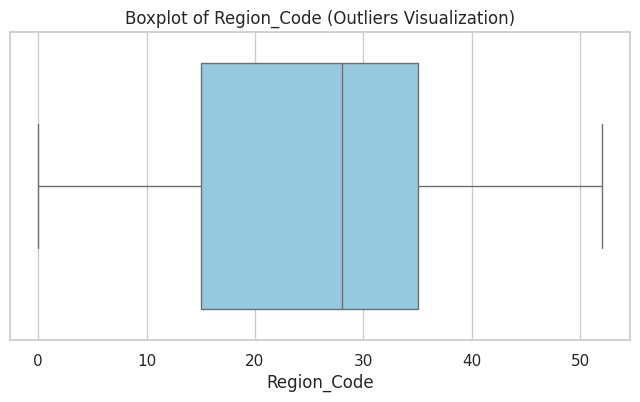

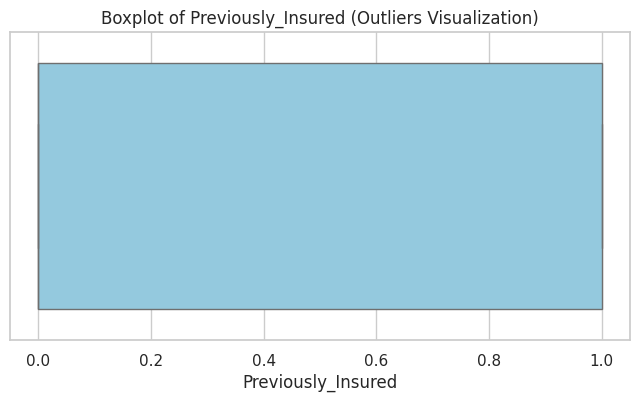

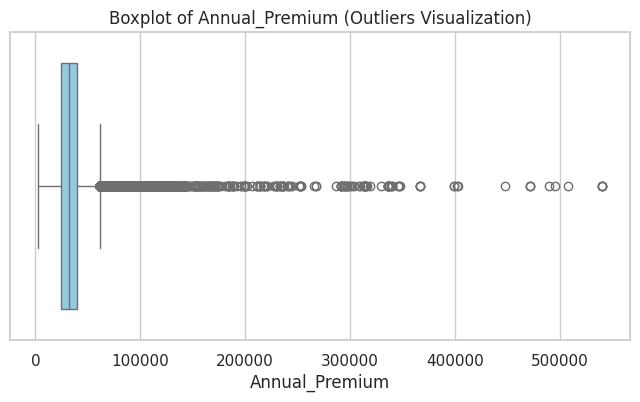

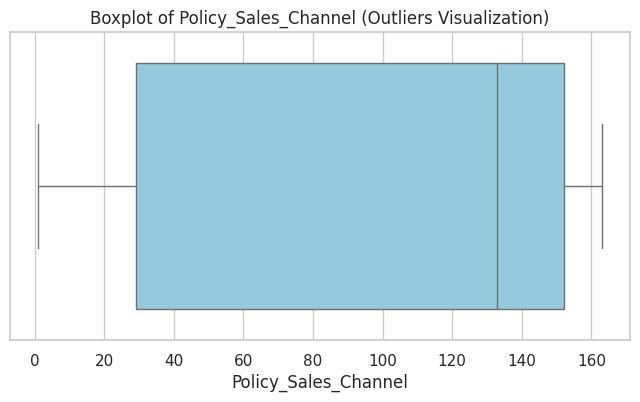

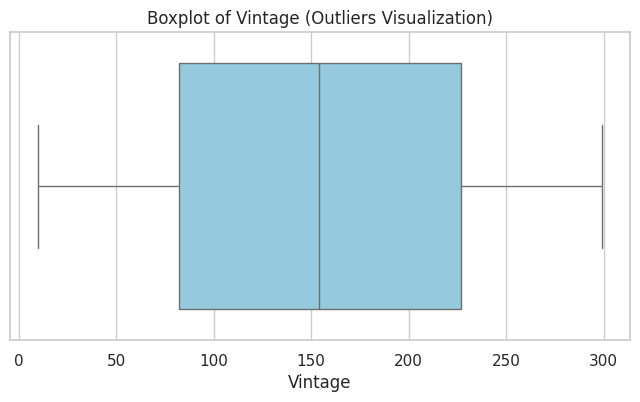

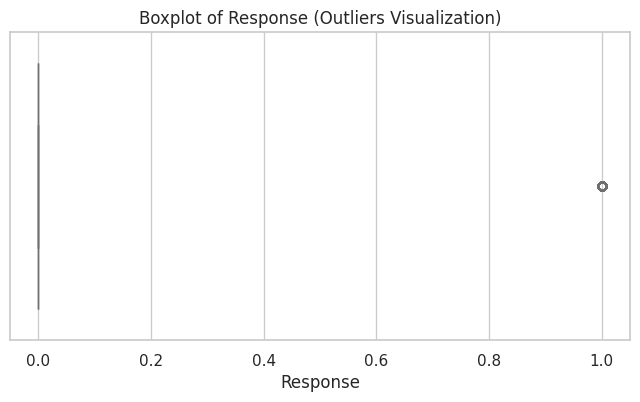

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot boxplots for all numerical columns
def plot_outliers(df_train):
    numerical_columns = df_train.select_dtypes(include=['float64', 'int64']).columns
    for column in numerical_columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df_train[column], color="skyblue")
        plt.title(f"Boxplot of {column} (Outliers Visualization)")
        plt.xlabel(column)
        plt.show()

# Call the function to plot
plot_outliers(df_train)

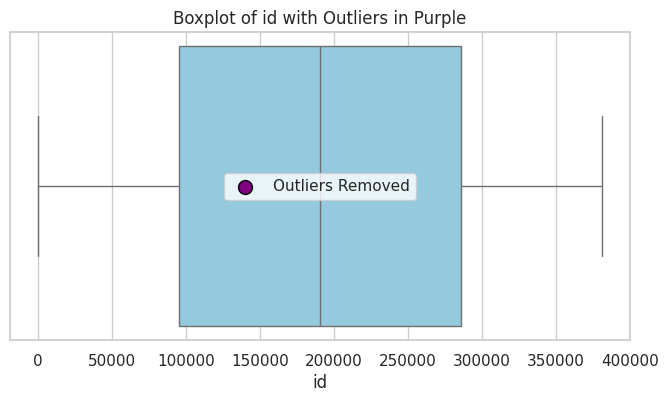

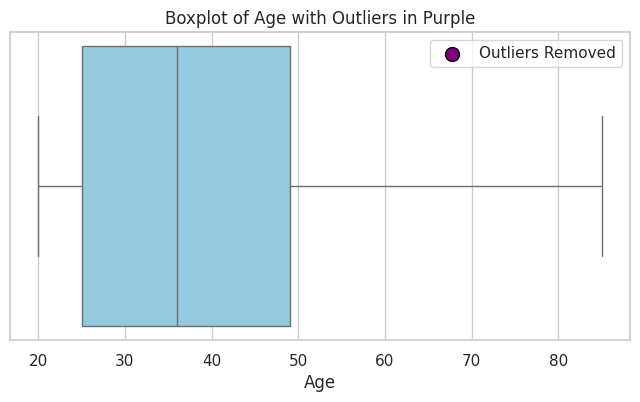

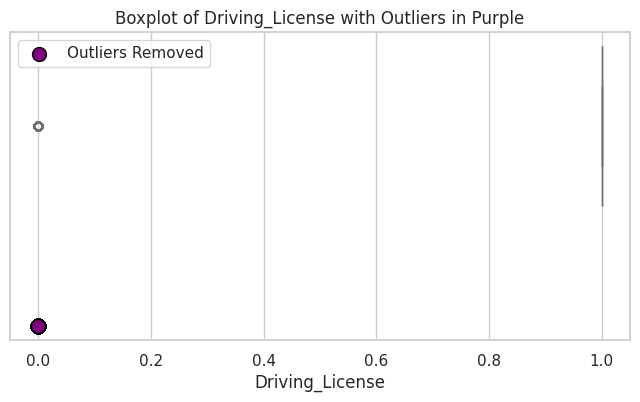

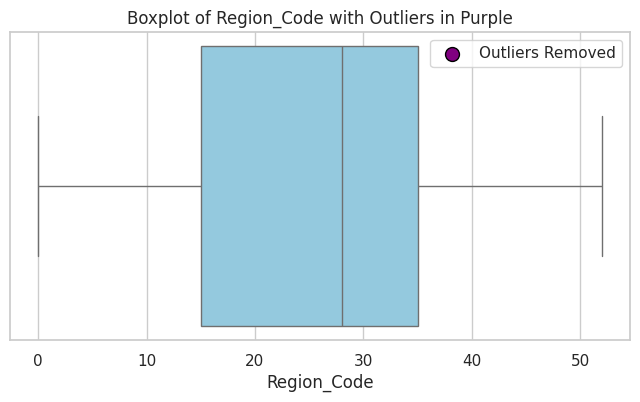

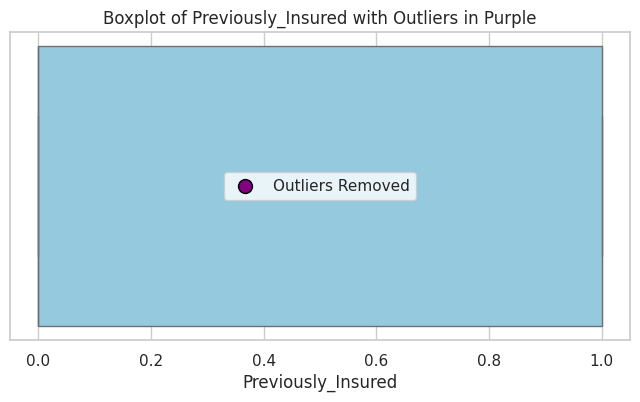

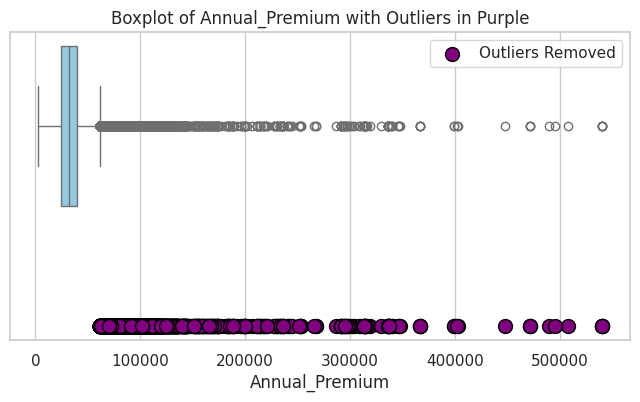

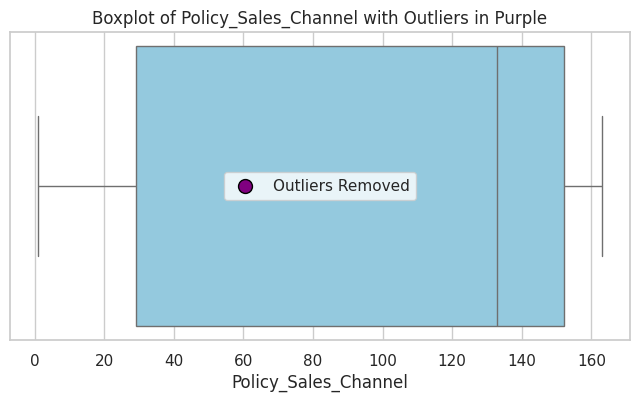

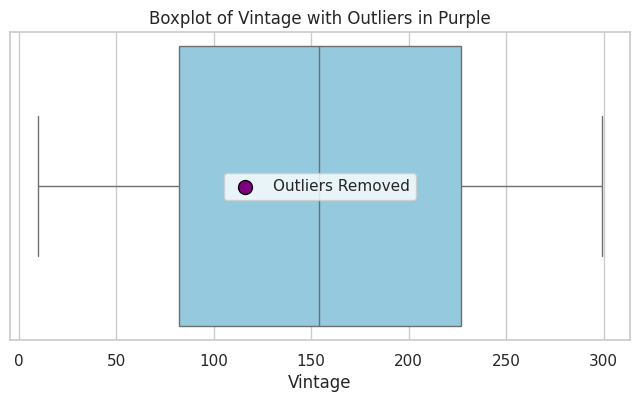

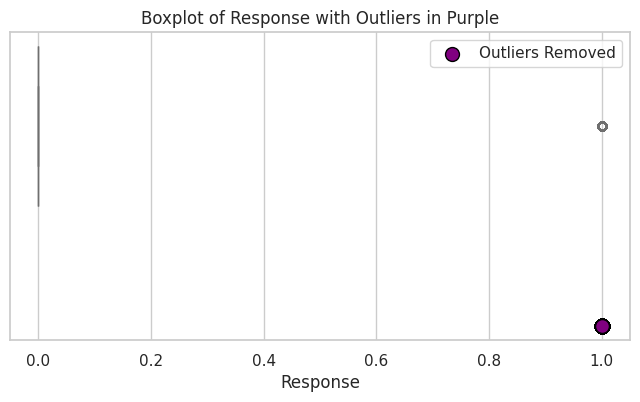

In [ ]:
def remove_outliers_iqr(df_train):
    cleaned_data = df_train.copy()
    outlier_data = {}

    for column in df_train.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df_train[column].quantile(0.25)
        Q3 = df_train[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_train[(df_train[column] < lower_bound) | (df_train[column] > upper_bound)]
        outlier_data[column] = outliers

        cleaned_data = cleaned_data[(cleaned_data[column] >= lower_bound) & (cleaned_data[column] <= upper_bound)]

    return cleaned_data, outlier_data

cleaned_data, outlier_data = remove_outliers_iqr(df_train)

def plot_outliers_with_removed(df_train, outlier_data):
    for column in df_train.select_dtypes(include=['float64', 'int64']).columns:
        plt.figure(figsize=(8, 4))

        # Plot original boxplot without highlighting outliers
        sns.boxplot(x=df_train[column], color="skyblue", flierprops={'marker': 'o', 'color': 'blue'})

        # Highlight the removed outliers in purple
        if column in outlier_data:
            outliers = outlier_data[column]
            plt.scatter(outliers[column], [1] * len(outliers), color="purple", label="Outliers Removed", s=100, edgecolor='black')

        plt.title(f"Boxplot of {column} with Outliers in Purple")
        plt.xlabel(column)
        plt.legend()
        plt.show()

plot_outliers_with_removed(df_train, outlier_data)

## knowing all the unique value in the columns

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [ ]:
df_train.describe(include = 'O')

,Gender,Vehicle_Age,Vehicle_Damage
count,381109,381109,381109
unique,2,3,2
top,Male,1-2 Year,Yes
freq,206089,200316,192413


In [ ]:
train_unique = df_train
for column in train_unique.columns:
    print(f"{column}: ")
    print("")
    print(train_unique[column].unique())
    print("")

id: 

[     1      2      3 ... 381107 381108 381109]

Gender: 

['Male' 'Female']

Age: 

[44 76 47 21 29 24 23 56 32 41 71 37 25 42 60 65 49 34 51 26 57 79 48 45
 72 30 54 27 38 22 78 20 39 62 58 59 63 50 67 77 28 69 52 31 33 43 36 53
 70 46 55 40 61 75 64 35 66 68 74 73 84 83 81 80 82 85]

Driving_License: 

[1 0]

Region_Code: 

[28.  3. 11. 41. 33.  6. 35. 50. 15. 45.  8. 36. 30. 26. 16. 47. 48. 19.
 39. 23. 37.  5. 17.  2.  7. 29. 46. 27. 25. 13. 18. 20. 49. 22. 44.  0.
  9. 31. 12. 34. 21. 10. 14. 38. 24. 40. 43. 32.  4. 51. 42.  1. 52.]

Previously_Insured: 

[0 1]

Vehicle_Age: 

['> 2 Years' '1-2 Year' '< 1 Year']

Vehicle_Damage: 

['Yes' 'No']

Annual_Premium: 

[ 40454.  33536.  38294. ...  20706. 101664.  69845.]

Policy_Sales_Channel: 

[ 26. 152. 160. 124.  14.  13.  30. 156. 163. 157. 122.  19.  22.  15.
 154.  16.  52. 155.  11. 151. 125.  25.  61.   1.  86.  31. 150.  23.
  60.  21. 121.   3. 139.  12.  29.  55.   7.  47. 127. 153.  78. 158.
  89.  32.   8.  10. 120.

**Encoding Object columns**

In [ ]:
df_train['Gender'] = df_train['Gender'].map({'Female':1, 'Male':0})
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,0,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,0,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,0,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,0,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,1,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
df_train['Vehicle_Damage'] = df_train['Vehicle_Damage'].map({'Yes':1, 'No':0})
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,0,44,1,28.0,0,> 2 Years,1,40454.0,26.0,217,1
1,2,0,76,1,3.0,0,1-2 Year,0,33536.0,26.0,183,0
2,3,0,47,1,28.0,0,> 2 Years,1,38294.0,26.0,27,1
3,4,0,21,1,11.0,1,< 1 Year,0,28619.0,152.0,203,0
4,5,1,29,1,41.0,1,< 1 Year,0,27496.0,152.0,39,0


In [ ]:
print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (381109, 12)
Test: (127037, 11)


In [ ]:
df_train['Vehicle_Age'] = df_train['Vehicle_Age'].map({'1-2 Year':1, '< 1 Year':0, '> 2 Years': 2})
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,0,44,1,28.0,0,2,1,40454.0,26.0,217,1
1,2,0,76,1,3.0,0,1,0,33536.0,26.0,183,0
2,3,0,47,1,28.0,0,2,1,38294.0,26.0,27,1
3,4,0,21,1,11.0,1,0,0,28619.0,152.0,203,0
4,5,1,29,1,41.0,1,0,0,27496.0,152.0,39,0


In [ ]:
df_train['Previously_Insured'] = df_train['Previously_Insured'].map({0:1,1:0})
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,0,44,1,28.0,1,2,1,40454.0,26.0,217,1
1,2,0,76,1,3.0,1,1,0,33536.0,26.0,183,0
2,3,0,47,1,28.0,1,2,1,38294.0,26.0,27,1
3,4,0,21,1,11.0,0,0,0,28619.0,152.0,203,0
4,5,1,29,1,41.0,0,0,0,27496.0,152.0,39,0


In [ ]:
# @title
# Set the option to suppress future warnings for silent downcasting
pd.set_option('future.no_silent_downcasting', True)


# Perform one-hot encoding on the 'Policy_Sales_Channel' column
one_hot_encoded_psc = pd.get_dummies(df_train['Policy_Sales_Channel'], prefix='PSC')

# Perform one-hot encoding on the 'Region_Code' column
one_hot_encoded_rc = pd.get_dummies(df_train['Region_Code'], prefix='RC')

# Concatenate the original DataFrame with the one-hot encoded columns
df_train_encoded = pd.concat([df_train,
                            one_hot_encoded_psc.astype('int32'),
                            one_hot_encoded_rc.astype('int32')], axis=1)

In [ ]:
df_train_encoded.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel',
       ...
       'RC_43.0', 'RC_44.0', 'RC_45.0', 'RC_46.0', 'RC_47.0', 'RC_48.0',
       'RC_49.0', 'RC_50.0', 'RC_51.0', 'RC_52.0'],
      dtype='object', length=220)

In [ ]:
df_train_encoded.shape

(381109, 220)

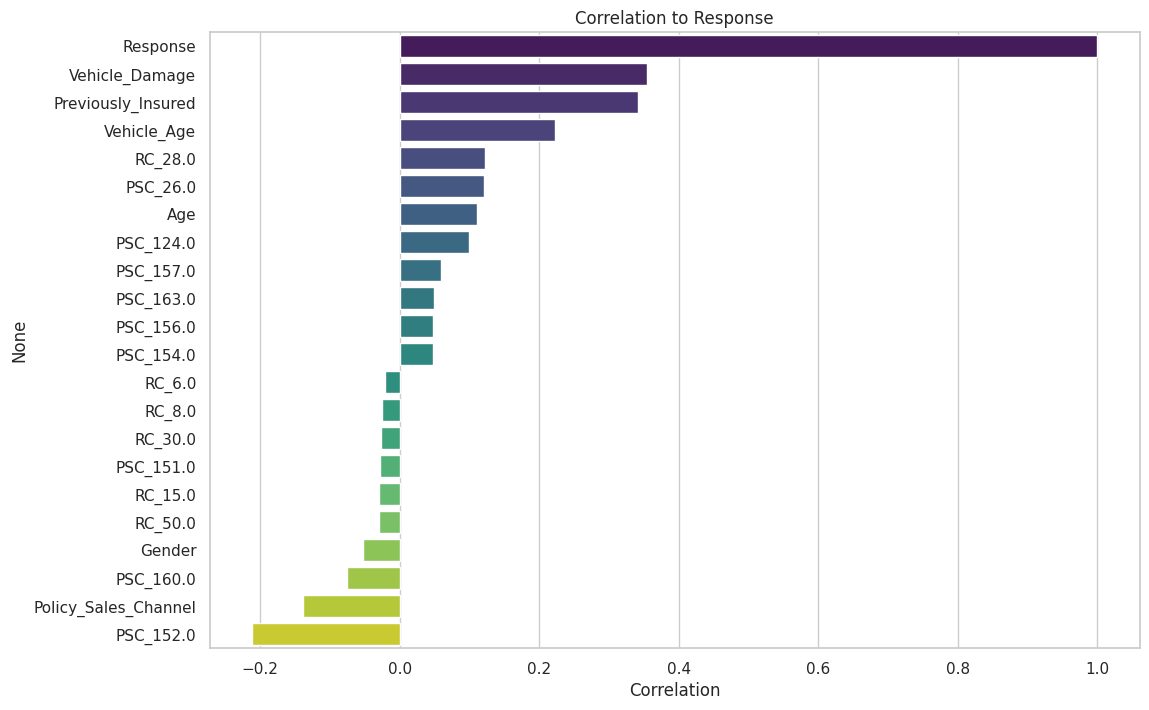

In [ ]:
# @title
def plot_top_bottom_rank_correlation(df, target, top_rank=10, bottom_rank=10, title=None):
    correlation = df.select_dtypes(include=['number']).corrwith(df[target]).sort_values(ascending=False)

    top_features = correlation.head(top_rank)
    bottom_features = correlation.tail(bottom_rank)
    selected_features = pd.concat([top_features, bottom_features])

    plt.figure(figsize=(12, 8))
    sns.barplot(x=selected_features.values, y=selected_features.index, palette='viridis')
    plt.xlabel('Correlation')
    plt.title(title if title else f'Top and Bottom {top_rank} Correlation with {target}')
    plt.show()

plot_top_bottom_rank_correlation(df_train_encoded, 'Response', top_rank=12, title='Correlation to Response')

In [ ]:
# @title
df_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Columns: 220 entries, id to RC_52.0
dtypes: float64(3), int32(208), int64(9)
memory usage: 337.3 MB


In [ ]:
# @title
print(df_train_encoded.select_dtypes(include='object').head())
print(df_train_encoded.select_dtypes(include='object').nunique())

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
Series([], dtype: float64)


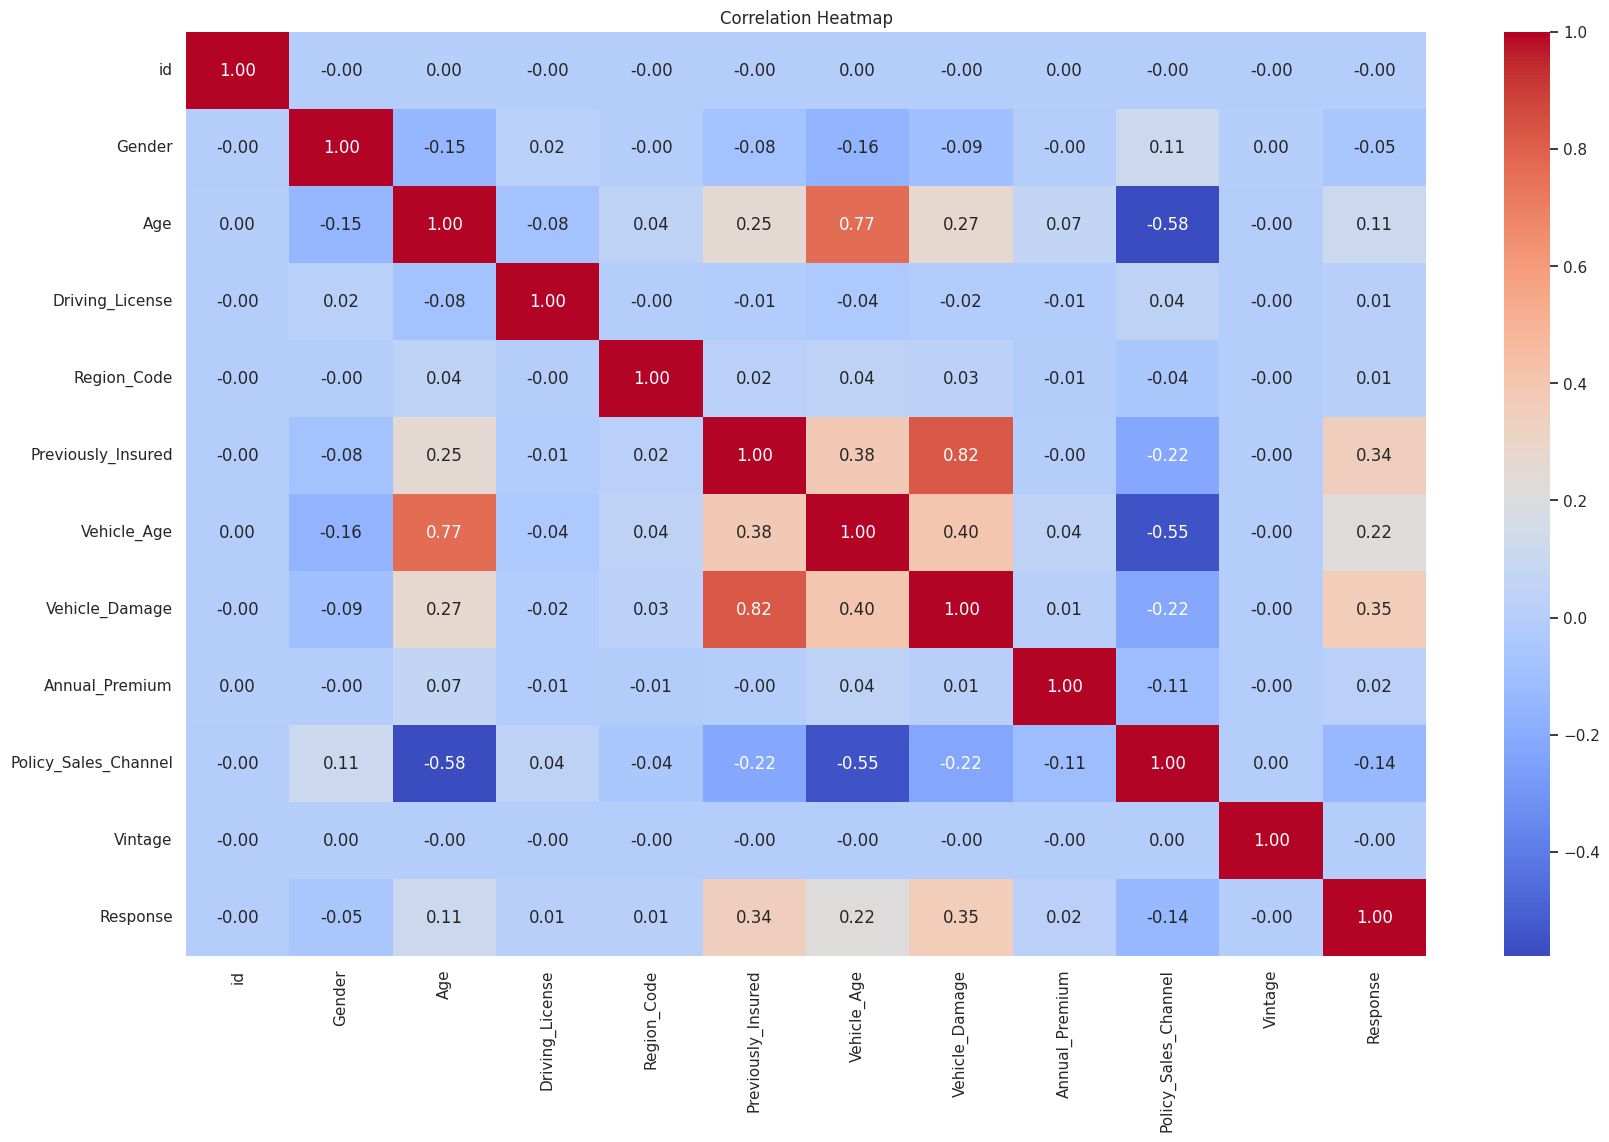

In [ ]:
plt.figure(figsize=(20, 12))
sns.heatmap(df_train.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# **Data Training**

RANDOM FOREST

In [ ]:
# Làm việc trên bản sao để an toàn
df = df_train.copy()

print("Kích thước:", df.shape)
print("Các cột:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)

# Khai báo target và cột nên loại bỏ khỏi X (nếu có)
TARGET_COL = "Response"   # chỉnh nếu khác
DROP_FEATURES = [c for c in ["id"] if c in df.columns]  # loại 'id' nếu có

# Kiểm tra target tồn tại
assert TARGET_COL in df.columns, f"Không tìm thấy cột target '{TARGET_COL}'!"

Kích thước: (381109, 12)
Các cột: ['id', 'Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Response']

Dtypes:
id                        int64
Gender                    int64
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age               int64
Vehicle_Damage            int64
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()

# 3.1) Encode theo thứ tự hợp lý nếu có các cột quen thuộc
if "Vehicle_Age" in df_enc.columns:
    age_map = {"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2}
    if df_enc["Vehicle_Age"].dtype == "object":
        df_enc["Vehicle_Age"] = df_enc["Vehicle_Age"].map(age_map)

if "Vehicle_Damage" in df_enc.columns and df_enc["Vehicle_Damage"].dtype == "object":
    bin_map = {"No": 0, "Yes": 1}
    df_enc["Vehicle_Damage"] = df_enc["Vehicle_Damage"].map(bin_map)

# 3.2) Encode mọi cột object còn lại bằng LabelEncoder
label_encoders = {}
for col in df_enc.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le

# Sanity check: không còn object
obj_left = df_enc.select_dtypes(include=["object"]).columns.tolist()
print("Object columns còn lại:", obj_left)
assert len(obj_left) == 0, "Vẫn còn cột object sau khi encode!"

print("✅ Encode xong. Dtypes:")
print(df_enc.dtypes)

# Dataset cuối để train
df_model = df_enc

Object columns còn lại: []
✅ Encode xong. Dtypes:
id                        int64
Gender                    int64
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age               int64
Vehicle_Damage            int64
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object


In [ ]:
# Cell 4 — Train/Test split
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[TARGET_COL] + DROP_FEATURES)
y = df_model[TARGET_COL]

print("Phân phối nhãn:")
print(y.value_counts(normalize=True).round(4))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước train:", X_train.shape, "| test:", X_test.shape)

# An toàn: bảo đảm không còn object
assert not len(X_train.select_dtypes(include=["object"]).columns), "X_train vẫn còn object!"
assert not len(X_test.select_dtypes(include=["object"]).columns), "X_test vẫn còn object!"

Phân phối nhãn:
Response
0    0.8774
1    0.1226
Name: proportion, dtype: float64
Kích thước train: (304887, 10) | test: (76222, 10)


In [ ]:
# Cell 5 — Huấn luyện Random Forest (sửa)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300, #--giảm estimator
    max_depth=9, #--Guiarm max depth
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)  # <-- đổi tên biến cho khớp Cell 60


NameError: name 'X_train_resampled' is not defined

In [ ]:
# 5) BẮT BUỘC: Đồng bộ cột test
X_test = X_test.reindex(columns=X_train_resampled.columns, fill_value=0)

In [ ]:
# ✅ Cell — Evaluation (đồng bộ cột theo schema model)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)

# 1) Lấy schema cột mà model đã học
required_cols = list(getattr(rf_model, "feature_names_in_", []))
if not required_cols:
    # Fallback nếu phiên bản sklearn không có thuộc tính này
    required_cols = list(X_train.columns)

# 2) Tạo bản làm việc cho X_test và bổ sung các cột còn thiếu
X_test_eval = X_test.copy()
missing = [c for c in required_cols if c not in X_test_eval.columns]

for c in missing:
    # Nếu có df_test và cột tồn tại trong df_test thì lấy từ đó, không thì điền 0
    if "df_test" in globals() and c in df_test.columns:
        X_test_eval[c] = df_test[c]
    else:
        X_test_eval[c] = 0

# 3) Loại bỏ cột thừa và sắp xếp đúng thứ tự cột
X_test_eval = X_test_eval.reindex(columns=required_cols, fill_value=0)

# 4) Dự đoán
y_pred = rf_model.predict(X_test_eval)

# 5) Tính proba & ROC-AUC (nếu có)
try:
    y_proba = rf_model.predict_proba(X_test_eval)[:, 1]
    rocauc = roc_auc_score(y_test, y_proba)
except Exception:
    y_proba = None
    rocauc = None

# 6) Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
if rocauc is not None:
    print(f"ROC-AUC  : {rocauc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 7) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["0","1"])
plt.yticks(tick_marks, ["0","1"])
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 8) ROC Curve (nếu có proba)
if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve - Random Forest")
    plt.show()


In [ ]:
# Cell A — Feature Importance từ RF hiện tại
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Lấy importance và map tên cột
feat_names = list(X_train_resampled.columns)
importances = getattr(rf_model, "feature_importances_", None)
assert importances is not None, "rf_model chưa có feature_importances_ — đã fit chưa?"

fi_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# 2) In top-k và lưu file (tuỳ chọn)
TOP_K = 20
print(f"Top {TOP_K} features quan trọng nhất:")
display(fi_df.head(TOP_K))

# Lưu CSV (tuỳ chọn)
# fi_df.to_csv("/mnt/data/rf_feature_importances.csv", index=False)

# 3) Vẽ biểu đồ barh cho Top-K
plt.figure(figsize=(8, max(4, TOP_K * 0.35)))
top = fi_df.head(TOP_K)[::-1]  # đảo để vẽ từ thấp lên cao
plt.barh(top["feature"], top["importance"])
plt.title(f"RandomForest Feature Importance — Top {TOP_K}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


NameError: name 'X_train_resampled' is not defined

***XGBOOST***

In [ ]:
# Cell 1 — Setup & helpers
try:
    import xgboost as xgb
except ImportError:
    !pip -q install xgboost
    import xgboost as xgb

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, classification_report, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# Đồng bộ cột giữa 2 DataFrame theo schema tham chiếu
def align_schema(X_ref: pd.DataFrame, X_new: pd.DataFrame) -> pd.DataFrame:
    return X_new.reindex(columns=X_ref.columns, fill_value=0)

# Tính F-beta (mặc định F2 ưu tiên Recall)
def fbeta_score_prec_rec(p, r, beta=2):
    num = (1+beta**2) * p * r
    den = (beta**2) * p + r + 1e-12
    return num / den


In [ ]:
# Cell 2 — Build X, y từ df_model (nếu chưa có X_train/X_test)
if 'X_train' not in globals() or 'X_test' not in globals():
    # Giả định bạn đã có df_model (đã encode, không còn object),
    # TARGET_COL và DROP_FEATURES giống notebook RF
    assert 'df_model' in globals(), "Chưa thấy df_model!"
    assert 'TARGET_COL' in globals(), "Chưa thấy TARGET_COL!"
    if 'DROP_FEATURES' not in globals():
        DROP_FEATURES = []

    X = df_model.drop(columns=[TARGET_COL] + DROP_FEATURES, errors='ignore')
    y = df_model[TARGET_COL]

    # Sanity check: không còn object
    assert not len(X.select_dtypes(include=['object']).columns), "X còn object, cần encode trước!"

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Pos rate train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))


In [ ]:
# Cell 3 — Compute scale_pos_weight
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = max((neg / max(pos, 1)), 1.0)
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg={neg}, pos={pos})")


In [ ]:
# Cell 4 — Train + chọn threshold trên validation
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Các cấu hình thử (nhỏ gọn nhưng hiệu quả)
param_grid = []
for n in [500, 800]:
    for lr in [0.05, 0.1]:
        for md in [4, 6, 8]:
            for mcl in [1, 2]:
                param_grid.append(dict(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=md,
                    min_child_weight=mcl,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_lambda=1.0,
                    gamma=0.0,
                    scale_pos_weight=scale_pos_weight
                ))

best = None  # (rec, f2, prec, thr, params, model)

for p in param_grid:
    clf = xgb.XGBClassifier(
        n_estimators=p["n_estimators"],
        learning_rate=p["learning_rate"],
        max_depth=p["max_depth"],
        min_child_weight=p["min_child_weight"],
        subsample=p["subsample"],
        colsample_bytree=p["colsample_bytree"],
        gamma=p["gamma"],
        reg_lambda=p["reg_lambda"],
        scale_pos_weight=p["scale_pos_weight"],
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_subtrain, y_subtrain)

    # Proba trên validation
    proba_val = clf.predict_proba(align_schema(X_subtrain, X_val))[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, proba_val)
    # thr có độ dài = len(prec)-1 -> tạo thr_full để index an toàn
    thr_full = np.r_[thr, 1.0]

    # Ràng buộc: muốn Recall cao nhưng Precision không tụt quá
    MIN_PREC = 0.35   # chỉnh theo business
    cand_idx = [i for i,(p_,r_) in enumerate(zip(prec,rec)) if p_ >= MIN_PREC]
    if not cand_idx:
        cand_idx = [int(np.argmax(rec))]  # không đạt min precision thì lấy recall cao nhất

    # Trong ứng viên: ưu tiên Recall, rồi F2
    best_i = max(cand_idx, key=lambda i: (rec[i], fbeta_score_prec_rec(prec[i], rec[i], beta=2)))
    cand = (rec[best_i], fbeta_score_prec_rec(prec[best_i], rec[best_i], 2),
            prec[best_i], thr_full[best_i], p, clf)

    if (best is None) or (cand[0] > best[0]) or (cand[0] == best[0] and cand[1] > best[1]):
        best = cand

best_rec, best_f2, best_prec, best_thr, best_params, best_model = best
print("✅ Best on VALIDATION")
print("Params:", best_params)
print(f"Threshold: {best_thr:.3f} | Recall: {best_rec:.4f} | Precision: {best_prec:.4f} | F2: {best_f2:.4f}")


In [ ]:
# Cell 4 — Train + chọn threshold trên validation
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Các cấu hình thử (nhỏ gọn nhưng hiệu quả)
param_grid = []
for n in [500, 800]:
    for lr in [0.05, 0.1]:
        for md in [4, 6, 8]:
            for mcl in [1, 2]:
                param_grid.append(dict(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=md,
                    min_child_weight=mcl,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_lambda=1.0,
                    gamma=0.0,
                    scale_pos_weight=scale_pos_weight
                ))

best = None  # (rec, f2, prec, thr, params, model)

for p in param_grid:
    clf = xgb.XGBClassifier(
        n_estimators=p["n_estimators"],
        learning_rate=p["learning_rate"],
        max_depth=p["max_depth"],
        min_child_weight=p["min_child_weight"],
        subsample=p["subsample"],
        colsample_bytree=p["colsample_bytree"],
        gamma=p["gamma"],
        reg_lambda=p["reg_lambda"],
        scale_pos_weight=p["scale_pos_weight"],
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_subtrain, y_subtrain)

    # Proba trên validation
    proba_val = clf.predict_proba(align_schema(X_subtrain, X_val))[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, proba_val)
    # thr có độ dài = len(prec)-1 -> tạo thr_full để index an toàn
    thr_full = np.r_[thr, 1.0]

    # Ràng buộc: muốn Recall cao nhưng Precision không tụt quá
    MIN_PREC = 0.35   # chỉnh theo business
    cand_idx = [i for i,(p_,r_) in enumerate(zip(prec,rec)) if p_ >= MIN_PREC]
    if not cand_idx:
        cand_idx = [int(np.argmax(rec))]  # không đạt min precision thì lấy recall cao nhất

    # Trong ứng viên: ưu tiên Recall, rồi F2
    best_i = max(cand_idx, key=lambda i: (rec[i], fbeta_score_prec_rec(prec[i], rec[i], beta=2)))
    cand = (rec[best_i], fbeta_score_prec_rec(prec[best_i], rec[best_i], 2),
            prec[best_i], thr_full[best_i], p, clf)

    if (best is None) or (cand[0] > best[0]) or (cand[0] == best[0] and cand[1] > best[1]):
        best = cand

best_rec, best_f2, best_prec, best_thr, best_params, best_model = best
print("✅ Best on VALIDATION")
print("Params:", best_params)
print(f"Threshold: {best_thr:.3f} | Recall: {best_rec:.4f} | Precision: {best_prec:.4f} | F2: {best_f2:.4f}")


In [ ]:
# Cell 5 — Refit best model trên toàn bộ train, đánh giá TEST
final_clf = xgb.XGBClassifier(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    min_child_weight=best_params["min_child_weight"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    gamma=best_params["gamma"],
    reg_lambda=best_params["reg_lambda"],
    scale_pos_weight=best_params["scale_pos_weight"],
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)
final_clf.fit(X_train, y_train)

# Đồng bộ schema rồi predict theo threshold đã chọn
X_test_eval = align_schema(X_train, X_test)
proba_test = final_clf.predict_proba(X_test_eval)[:, 1]
y_pred_test = (proba_test >= best_thr).astype(int)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)
try:
    rocauc = roc_auc_score(y_test, proba_test)
except Exception:
    rocauc = None

print("\n🎯 TEST METRICS (XGBoost, threshold từ VALIDATION)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
if rocauc is not None:
    print(f"ROC-AUC  : {rocauc:.4f}")

print("\nClassification Report (TEST):")
print(classification_report(y_test, y_pred_test, zero_division=0))


# **Apply data Prediction**

In [ ]:
# Đồng bộ schema giữa X_test và X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Dự đoán xác suất
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
# Tạo bảng dự đoán gồm ID, xác suất và thứ hạng (bản sửa lỗi KeyError)
df_result = pd.DataFrame({
    'Customer_ID': df_test['id'].values[:len(y_pred_prob)],   # lấy theo thứ tự dòng
    'Predicted_Probability': y_pred_prob
}).sort_values('Predicted_Probability', ascending=False).reset_index(drop=True)

df_result['Rank'] = df_result.index + 1
df_result.head(10)

In [ ]:
# Phân nhóm khách hàng theo xác suất dự đoán
def segment_customer(prob):
    if prob >= 0.8:
        return "High Potential"
    elif prob >= 0.5:
        return "Medium Potential"
    else:
        return "Low Potential"

df_result["Segment"] = df_result["Predicted_Probability"].apply(segment_customer)

# Đếm số lượng từng nhóm
segment_summary = df_result["Segment"].value_counts().reset_index()
segment_summary.columns = ["Segment", "Customer_Count"]

print(segment_summary)
df_result.head(10)

In [ ]:
# Trực quan hóa & Chiến lược thông minh
import matplotlib.pyplot as plt

# Vẽ biểu đồ cột thể hiện số lượng khách hàng từng nhóm
plt.figure(figsize=(7,5))
plt.bar(segment_summary["Segment"], segment_summary["Customer_Count"], color=['lightcoral', 'gold', 'lightgreen'])
plt.title("Customer Segmentation by Predicted Probability")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Tính tỷ lệ phần trăm từng nhóm
segment_summary["Percentage"] = (segment_summary["Customer_Count"] / segment_summary["Customer_Count"].sum() * 100).round(2)
print(segment_summary)

In [ ]:
# Xuất nhóm khách hàng tiềm năng
top_customers = df_result[df_result["Segment"] == "High Potential"].copy()
top_customers.to_csv("Top_HighPotential_Customers.csv", index=False)

print(top_customers.head(10))

In [ ]:
# Trực quan hóa – Phân phối xác suất
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_result["Predicted_Probability"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Predicted Purchase Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Đánh giá hiệu suất mô hình (Precision@K hoặc Lift Chart)
import numpy as np

# Ví dụ: tính độ chính xác top 10%
K = int(0.10 * len(y_test))  # top 10% khách hàng
idx_top = np.argsort(-y_pred_prob)[:K]
precision_at_10 = y_test.values[idx_top].sum() / K

# Lift chart (tuỳ chọn)
df_lift = pd.DataFrame({'y_true': y_test.values, 'y_score': y_pred_prob})
df_lift['decile'] = pd.qcut(df_lift['y_score'], 10, labels=False, duplicates='drop')
lift_table = (
    df_lift.groupby('decile')['y_true']
    .agg(['count', 'mean'])
    .sort_index(ascending=False)
    .rename(columns={'mean': 'response_rate'})
)
baseline = df_lift['y_true'].mean()
lift_table['lift'] = lift_table['response_rate'] / baseline
print("\n📈 Lift Table:")
display(lift_table)

In [ ]:
# Kiểm tra đạo đức (Fairness by Gender)
if 'Gender' in df_test.columns:
    df_result['Gender'] = df_test['Gender']
    fairness_check = df_result.groupby('Gender')['Predicted_Probability'].mean()
    print("Hoàn tất kiểm tra tính công bằng theo Giới tính:")
    display(fairness_check)
else:
    print("Cột giới tính không có sẵn.")

In [ ]:
from sklearn.calibration import calibration_curve

# Tính calibration (trả về: fraction_of_positives, mean_predicted_value)
frac_pos, mean_pred = calibration_curve(y_test, y_pred_prob, n_bins=10, strategy='quantile')

plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, marker='o', label='Model')
plt.plot([0,1],[0,1], '--', color='gray', label='Perfectly calibrated')
plt.title("Calibration Curve – Probability Reliability")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Purchase Rate (Fraction of Positives)")
plt.legend(); plt.grid(alpha=0.3); plt.show()